iter 0: ll=323222.20
iter 1: ll=568158.62
iter 2: ll=627668.02
iter 3: ll=650493.20
iter 4: ll=665266.01
iter 5: ll=676576.65
iter 6: ll=685443.61
iter 7: ll=692373.47
iter 8: ll=697735.14
iter 9: ll=701787.09
iter 10: ll=704702.12
iter 11: ll=706628.75
iter 12: ll=707745.06
iter 13: ll=708261.43
iter 14: ll=708390.28
iter 15: ll=708309.02
iter 16: ll=708141.38
iter 17: ll=707959.76
iter 18: ll=707798.79
iter 19: ll=707670.09
iter 20: ll=707573.60
iter 21: ll=707504.45
iter 22: ll=707456.66
iter 23: ll=707424.71
iter 24: ll=707404.13
iter 25: ll=707391.48
iter 26: ll=707384.24
iter 27: ll=707380.63
iter 28: ll=707379.41
iter 29: ll=707379.70


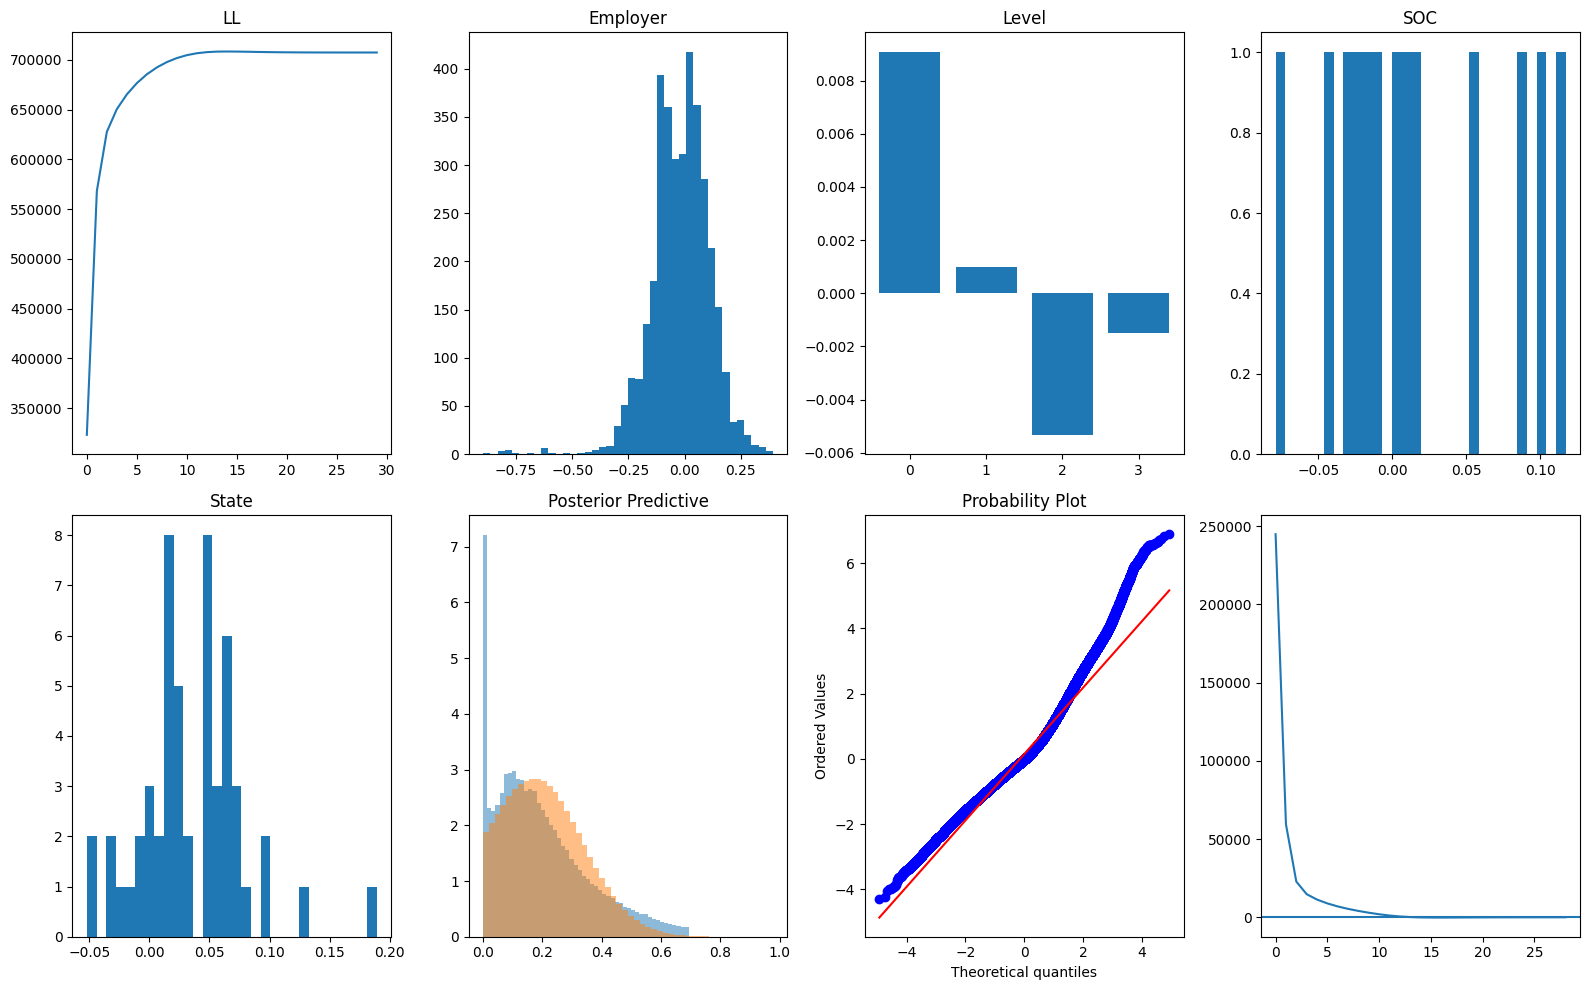

In [1]:
# =========================
# FINAL CLEAN EM (WARMUP + FREEZE VARIANCES)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

EPS = 1e-6
MAX_VAL = 1e6

# =========================
# DATA PREP
# =========================

def prepare_data(df):

    df = df.copy()

    df["SOC_2DIGIT"] = df["SOC_CODE"].astype(str).str[:2]
    soc_counts = df["SOC_2DIGIT"].value_counts()
    df["SOC_F"] = df["SOC_2DIGIT"].where(
        df["SOC_2DIGIT"].isin(soc_counts[soc_counts >= 100].index),
        "OTHER"
    )

    state_counts = df["WORKSITE_STATE"].value_counts()
    df["STATE_F"] = df["WORKSITE_STATE"].where(
        df["WORKSITE_STATE"].isin(state_counts[state_counts >= 100].index),
        "OTHER"
    )

    S = pd.Categorical(df["SOC_F"]).codes
    ST = pd.Categorical(df["STATE_F"]).codes
    E = pd.Categorical(df["EMPLOYER_NAME_CLEAN"]).codes

    level_map = {"I":0,"II":1,"III":2,"IV":3}
    L = df["WAGE_LEVEL_CLEAN"].map(level_map).values

    y = np.maximum(np.log(df["wage_ratio"].values), 0)
    censored = (y == 0)

    return {
        "y": y,
        "censored": censored,
        "L": L,
        "E": E,
        "S": S,
        "ST": ST,
        "K": 4,
        "N_E": len(np.unique(E)),
        "N_S": len(np.unique(S)),
        "N_ST": len(np.unique(ST))
    }

# =========================
# E STEP
# =========================

def truncated_normal_moments(mu, sigma):

    sigma = np.maximum(sigma, EPS)
    alpha = np.clip(-mu / sigma, -10, 10)

    phi = stats.norm.pdf(alpha)
    Phi = np.clip(stats.norm.cdf(alpha), 1e-10, 1.0)

    ratio = np.clip(phi / Phi, -MAX_VAL, MAX_VAL)

    E1 = mu - sigma * ratio
    E2 = mu**2 + sigma**2 - sigma * (mu + sigma * ratio) * ratio

    return E1, E2

def e_step(y, censored, mu, sigma):

    y_star = y.copy()
    y_star2 = y**2

    if censored.any():
        E1, E2 = truncated_normal_moments(mu[censored], sigma)
        y_star[censored] = E1
        y_star2[censored] = E2

    return y_star, y_star2

# =========================
# SAFE VARIANCE UPDATES
# =========================

def update_sigma(alpha):
    return max((np.sum(alpha**2) + 0.1) / (len(alpha) + 2), 1e-4)

def update_sigma2(resid2):
    return max((np.sum(resid2) + 0.1) / (len(resid2) + 2), 1e-4)

def damp(old, new, w=0.1):
    return (1-w)*old + w*new

# =========================
# M STEP (MEANS ONLY)
# =========================

def m_step(y_star, y_star2, L, E, S, ST,
           gamma, alpha, delta, eta,
           sigma2, sigma_E2, sigma_L2, sigma_S2, sigma_ST2):

    n = len(y_star)

    lam_L = min(sigma2 / sigma_L2, MAX_VAL)
    lam_E = min(sigma2 / sigma_E2, MAX_VAL)
    lam_S = min(sigma2 / sigma_S2, MAX_VAL)
    lam_ST = min(sigma2 / sigma_ST2, MAX_VAL)

    K, N_E, N_S, N_ST = len(gamma), len(alpha), len(delta), len(eta)

    n_L = np.bincount(L, minlength=K)
    n_E = np.bincount(E, minlength=N_E)
    n_S = np.bincount(S, minlength=N_S)
    n_ST = np.bincount(ST, minlength=N_ST)

    Sy_L = np.bincount(L, weights=y_star, minlength=K)
    Sy_E = np.bincount(E, weights=y_star, minlength=N_E)
    Sy_S = np.bincount(S, weights=y_star, minlength=N_S)
    Sy_ST = np.bincount(ST, weights=y_star, minlength=N_ST)

    Sy_total = y_star.sum()

    for _ in range(30):

        beta0 = (Sy_total - (gamma[L] + alpha[E] + delta[S] + eta[ST]).sum()) / n

        gamma = (Sy_L - np.bincount(L, weights=alpha[E]+delta[S]+eta[ST], minlength=K) - n_L*beta0) / (n_L + lam_L)
        alpha = (Sy_E - np.bincount(E, weights=gamma[L]+delta[S]+eta[ST], minlength=N_E) - n_E*beta0) / (n_E + lam_E)
        delta = (Sy_S - np.bincount(S, weights=gamma[L]+alpha[E]+eta[ST], minlength=N_S) - n_S*beta0) / (n_S + lam_S)
        eta   = (Sy_ST - np.bincount(ST, weights=gamma[L]+alpha[E]+delta[S], minlength=N_ST) - n_ST*beta0) / (n_ST + lam_ST)

    mu = beta0 + gamma[L] + alpha[E] + delta[S] + eta[ST]

    resid2 = np.clip(y_star2 - 2*y_star*mu + mu**2, 0, MAX_VAL)
    sigma2 = update_sigma2(resid2)

    return beta0, gamma, alpha, delta, eta, sigma2, mu

# =========================
# LOG LIKELIHOOD
# =========================

def observed_ll(y, censored, mu, sigma):

    sigma = max(sigma, 1e-4)

    ll = 0
    if (~censored).any():
        ll += stats.norm.logpdf(y[~censored], mu[~censored], sigma).sum()

    if censored.any():
        ll += np.log(np.clip(stats.norm.cdf(0, mu[censored], sigma), 1e-10, 1)).sum()

    return ll

# =========================
# FIT MODEL
# =========================

def fit_model(data, max_iter=50):

    y, censored = data['y'], data['censored']
    L, E, S, ST = data['L'], data['E'], data['S'], data['ST']

    gamma = np.zeros(data['K'])
    alpha = np.zeros(data['N_E'])
    delta = np.zeros(data['N_S'])
    eta   = np.zeros(data['N_ST'])

    beta0 = np.mean(y)

    sigma2 = 1.0
    sigma_E2 = sigma_L2 = sigma_S2 = sigma_ST2 = 0.1

    lls = []
    history = []

    for it in range(max_iter):

        mu = beta0 + gamma[L] + alpha[E] + delta[S] + eta[ST]

        y_star, y_star2 = e_step(y, censored, mu, np.sqrt(sigma2))

        beta0, gamma, alpha, delta, eta, sigma2, mu = m_step(
            y_star, y_star2, L, E, S, ST,
            gamma, alpha, delta, eta,
            sigma2, sigma_E2, sigma_L2, sigma_S2, sigma_ST2
        )

        # 🔥 Warmup → Freeze
        if it < 10:
            sigma_E2 = damp(sigma_E2, update_sigma(alpha))
            sigma_L2 = damp(sigma_L2, update_sigma(gamma))
            sigma_S2 = damp(sigma_S2, update_sigma(delta))
            sigma_ST2 = damp(sigma_ST2, update_sigma(eta))

        ll = observed_ll(y, censored, mu, np.sqrt(sigma2))
        lls.append(ll)

        history.append({
            "sigma": np.sqrt(sigma2),
            "sigma_E": np.sqrt(sigma_E2),
            "sigma_L": np.sqrt(sigma_L2),
            "sigma_S": np.sqrt(sigma_S2),
            "sigma_ST": np.sqrt(sigma_ST2)
        })

        print(f"iter {it}: ll={ll:.2f}")

        if it > 2 and abs(lls[-1] - lls[-2]) < 1:
            break

    return {
        "beta0": beta0,
        "gamma": gamma,
        "alpha": alpha,
        "delta": delta,
        "eta": eta,
        "sigma": np.sqrt(sigma2),
        "lls": lls,
        "history": history,
        "data": data
    }

# =========================
# DIAGNOSTICS
# =========================

def plot_results(result):

    data = result["data"]
    mu = (result["beta0"]
          + result["gamma"][data["L"]]
          + result["alpha"][data["E"]]
          + result["delta"][data["S"]]
          + result["eta"][data["ST"]])

    sigma = result["sigma"]
    y = data["y"]

    fig = plt.figure(figsize=(16,10))
    gs = gridspec.GridSpec(2,4)

    plt.subplot(gs[0,0]); plt.plot(result["lls"]); plt.title("LL")
    plt.subplot(gs[0,1]); plt.hist(result["alpha"], bins=40); plt.title("Employer")
    plt.subplot(gs[0,2]); plt.bar(range(4), result["gamma"]); plt.title("Level")
    plt.subplot(gs[0,3]); plt.hist(result["delta"], bins=30); plt.title("SOC")

    plt.subplot(gs[1,0]); plt.hist(result["eta"], bins=30); plt.title("State")

    plt.subplot(gs[1,1])
    y_sim = np.maximum(np.random.normal(mu, sigma), 0)
    plt.hist(y[y>0], bins=50, density=True, alpha=0.5)
    plt.hist(y_sim[y_sim>0], bins=50, density=True, alpha=0.5)
    plt.title("Posterior Predictive")

    plt.subplot(gs[1,2])
    stats.probplot((y[y>0]-mu[y>0])/sigma, plot=plt)

    plt.subplot(gs[1,3])
    plt.plot(np.diff(result["lls"]))
    plt.axhline(0)

    plt.tight_layout()
    plt.show()

# =========================
# RUN
# =========================

if __name__ == "__main__":

    df = pd.read_parquet("../data/final_filtered.parquet")

    df = df[(df.wage_ratio < 2) & (df.wage_ratio > 0.5)]
    df = df[df["EMPLOYER_NAME_CLEAN"].map(df["EMPLOYER_NAME_CLEAN"].value_counts()) >= 100]

    data = prepare_data(df)

    result = fit_model(data)

    plot_results(result)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

def simulate_yrep(result, n_sim=50, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)
    data  = result["data"]
    sigma = result["sigma"]
    mu = (result["beta0"]
          + result["gamma"][data["L"]]
          + result["alpha"][data["E"]]
          + result["delta"][data["S"]]
          + result["eta"][data["ST"]])
    y_rep = np.maximum(
        rng.normal(mu[None, :], sigma, size=(n_sim, len(mu))), 0.0
    )
    return y_rep, mu

# def simulate_yrep(result, n_sim=50, rng=None):
#     if rng is None:
#         rng = np.random.default_rng(42)
#     data  = result["data"]
#     sigma = result["sigma"]
#     pi_E  = result["pi_E"]
#     E     = data["E"]

#     mu = (result["beta0"]
#           + result["gamma"][data["L"]]
#           + result["alpha"][data["E"]]
#           + result["delta"][data["S"]]
#           + result["eta"][data["ST"]])

#     pi_obs = pi_E[E]   # per-observation structural-zero probability
#     n      = len(mu)

#     y_rep = np.zeros((n_sim, n))
#     for s in range(n_sim):
#         z_struct = rng.random(n) < pi_obs          # structural zeros
#         y_cont   = rng.normal(mu, sigma)
#         y_tobit  = np.maximum(y_cont, 0.0)
#         y_rep[s] = np.where(z_struct, 0.0, y_tobit)

#     return y_rep, mu


# ─────────────────────────────────────────────────────────────────────────────
# CHECK 1: Global distribution of uncensored wages
# Tests: does the model reproduce the overall shape, mean, and spread
# of positive log wage ratios?
# ─────────────────────────────────────────────────────────────────────────────

def ppc_global_distribution(result, df, n_sim=500):
    """
    Overlay observed density vs posterior predictive density (uncensored only).
    Also compares: mean, SD, 10th/50th/90th percentiles.
    """
    y      = result["data"]["y"]
    y_rep, _ = simulate_yrep(result, n_sim=n_sim)

    obs_pos  = y[y > 0]
    rep_pos  = [yr[yr > 0] for yr in y_rep]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── left: density overlay ────────────────────────────────────────────────
    ax = axes[0]
    bins = np.linspace(0, obs_pos.max() * 1.05, 80)

    # posterior predictive envelope
    rep_hists = np.array([np.histogram(r, bins=bins, density=True)[0]
                           for r in rep_pos])
    lo, hi = np.percentile(rep_hists, [5, 95], axis=0)
    mid    = np.percentile(rep_hists, 50, axis=0)
    bw     = bins[1] - bins[0]
    bc     = bins[:-1] + bw / 2

    ax.fill_between(bc, lo, hi, alpha=0.3, color="steelblue", label="PPC 90% band")
    ax.plot(bc, mid, color="steelblue", lw=1.5, label="PPC median")
    obs_h, _ = np.histogram(obs_pos, bins=bins, density=True)
    ax.step(bc, obs_h, where="mid", color="black", lw=1.5, label="Observed")
    ax.set_xlabel("log(wage / prevailing wage)  [uncensored]")
    ax.set_ylabel("Density")
    ax.set_title("CHECK 1a: Overall density of uncensored wages")
    ax.legend(fontsize=9)

    # ── right: test-statistic table ──────────────────────────────────────────
    ax = axes[1]
    ax.axis("off")

    def pval(obs_stat, rep_stats):
        return np.mean(rep_stats >= obs_stat)

    stats_obs = {
        "Mean":    obs_pos.mean(),
        "SD":      obs_pos.std(),
        "p10":     np.percentile(obs_pos, 10),
        "Median":  np.median(obs_pos),
        "p90":     np.percentile(obs_pos, 90),
        "Skew":    stats.skew(obs_pos),
        "Kurtosis":stats.kurtosis(obs_pos),
    }
    rows = []
    for name, obs_val in stats_obs.items():
        fn    = {
            "Mean":     lambda r: r.mean(),
            "SD":       lambda r: r.std(),
            "p10":      lambda r: np.percentile(r, 10),
            "Median":   lambda r: np.median(r),
            "p90":      lambda r: np.percentile(r, 90),
            "Skew":     lambda r: stats.skew(r),
            "Kurtosis": lambda r: stats.kurtosis(r),
        }[name]
        rep_vals = np.array([fn(r) for r in rep_pos])
        pv = pval(obs_val, rep_vals)
        flag = "⚠" if (pv < 0.05 or pv > 0.95) else "✓"
        rows.append([name,
                     f"{obs_val:.4f}",
                     f"{rep_vals.mean():.4f}",
                     f"{pv:.3f}",
                     flag])

    tbl = ax.table(
        cellText=rows,
        colLabels=["Statistic", "Observed", "PPC Mean", "p-value", ""],
        loc="center", cellLoc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.6)
    ax.set_title("CHECK 1b: Test statistics\n(p-value: fraction of sims ≥ observed)",
                 fontsize=10, pad=12)

    plt.tight_layout()
    plt.savefig("figures/ppc_01_global.png", dpi=150, bbox_inches="tight")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# CHECK 2: Censoring rate  (fraction with y=0)
# Tests: does the model reproduce the overall bunching fraction, AND
# does it reproduce censoring rates within each wage level?
# ─────────────────────────────────────────────────────────────────────────────

def ppc_censoring(result, n_sim=500):
    """
    Compare observed vs predicted censoring rate overall and by wage level.
    """
    data     = result["data"]
    y        = data["y"]
    L        = data["L"]
    y_rep, _ = simulate_yrep(result, n_sim=n_sim)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── left: overall censoring distribution ─────────────────────────────────
    ax = axes[0]
    rep_cens = (y_rep == 0).mean(axis=1)   # one value per sim
    obs_cens = (y == 0).mean()

    ax.hist(rep_cens, bins=40, density=True, color="steelblue",
            alpha=0.7, label="PPC")
    ax.axvline(obs_cens, color="black", lw=2,
               label=f"Observed ({obs_cens:.3f})")
    pv = np.mean(rep_cens >= obs_cens)
    ax.set_xlabel("Fraction censored")
    ax.set_ylabel("Density")
    ax.set_title(f"CHECK 2a: Overall censoring rate\n(p-value = {pv:.3f})")
    ax.legend()

    # ── right: by wage level ─────────────────────────────────────────────────
    ax = axes[1]
    level_labels = ["I", "II", "III", "IV"]
    x = np.arange(4)
    width = 0.35

    obs_by_level = np.array([(y[L == k] == 0).mean() for k in range(4)])
    rep_by_level = np.array([
        [(y_rep[s][L == k] == 0).mean() for k in range(4)]
        for s in range(n_sim)
    ])
    rep_lo = np.percentile(rep_by_level, 5,  axis=0)
    rep_hi = np.percentile(rep_by_level, 95, axis=0)
    rep_mid = rep_by_level.mean(axis=0)

    ax.bar(x - width/2, obs_by_level, width, label="Observed",
           color="black", alpha=0.8)
    ax.bar(x + width/2, rep_mid, width, label="PPC mean",
           color="steelblue", alpha=0.8)
    ax.errorbar(x + width/2, rep_mid,
                yerr=[rep_mid - rep_lo, rep_hi - rep_mid],
                fmt="none", color="navy", capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Level {l}" for l in level_labels])
    ax.set_ylabel("Fraction censored")
    ax.set_title("CHECK 2b: Censoring rate by wage level")
    ax.legend()

    plt.tight_layout()
    plt.savefig("figures/ppc_02_censoring.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("Observed censoring by level:", dict(zip(level_labels, obs_by_level.round(3))))
    print("PPC mean censoring by level:", dict(zip(level_labels, rep_mid.round(3))))


# ─────────────────────────────────────────────────────────────────────────────
# CHECK 3: Distribution by wage level
# Tests: does the model reproduce the shape within each level group?
# The Tobit uses a single global sigma — failures here reveal
# heteroskedasticity across levels.
# ─────────────────────────────────────────────────────────────────────────────

def ppc_by_level(result, n_sim=200):
    """
    For each wage level: observed vs PPC density of uncensored wages.
    Failure = model uses wrong spread for a given level.
    """
    data     = result["data"]
    y, L     = data["y"], data["L"]
    y_rep, _ = simulate_yrep(result, n_sim=n_sim)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    level_labels = ["I", "II", "III", "IV"]

    for k, (ax, lbl) in enumerate(zip(axes.flatten(), level_labels)):
        mask = (L == k)
        obs_pos = y[mask]; obs_pos = obs_pos[obs_pos > 0]

        if len(obs_pos) < 20:
            ax.set_title(f"Level {lbl}: too few obs"); continue

        bins = np.linspace(0, np.percentile(obs_pos, 99) * 1.1, 60)
        rep_hists = []
        for yr in y_rep:
            rp = yr[mask]; rp = rp[rp > 0]
            h, _ = np.histogram(rp, bins=bins, density=True)
            rep_hists.append(h)
        rep_hists = np.array(rep_hists)
        lo, hi = np.percentile(rep_hists, [5, 95], axis=0)
        mid    = rep_hists.mean(axis=0)
        bw = bins[1] - bins[0]; bc = bins[:-1] + bw/2

        ax.fill_between(bc, lo, hi, alpha=0.3, color="steelblue",
                         label="PPC 90%")
        ax.plot(bc, mid, color="steelblue", lw=1.5)
        obs_h, _ = np.histogram(obs_pos, bins=bins, density=True)
        ax.step(bc, obs_h, where="mid", color="black", lw=1.5,
                label="Observed")

        # flag mean and SD mismatch
        rep_means = np.array([yr[mask][yr[mask] > 0].mean() for yr in y_rep])
        rep_sds   = np.array([yr[mask][yr[mask] > 0].std()  for yr in y_rep])
        pv_m = np.mean(rep_means >= obs_pos.mean())
        pv_s = np.mean(rep_sds   >= obs_pos.std())

        ax.set_title(f"Level {lbl}  (n={len(obs_pos):,})\n"
                     f"mean p={pv_m:.3f}  SD p={pv_s:.3f}",
                     fontsize=10)
        ax.set_xlabel("log(wage ratio)  [uncensored]")
        ax.legend(fontsize=8)

    plt.suptitle("CHECK 3: Distribution by Wage Level\n"
                 "p-values outside [0.05, 0.95] indicate misfit",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("figures/ppc_03_by_level.png", dpi=150, bbox_inches="tight")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# CHECK 4: Employer-level censoring rates
# Tests: does the model reproduce the DISTRIBUTION of per-employer
# censoring rates? Failure = model too optimistic / pessimistic about
# how much bunching varies across employers.
# ─────────────────────────────────────────────────────────────────────────────

def ppc_employer_censoring(result, n_sim=200, min_apps=50):
    """
    Compare the distribution (across employers) of per-employer censoring rates.
    Also flags the worst-fit employers by name.
    """
    data     = result["data"]
    y, E     = data["y"], data["E"]
    N_E      = data["N_E"]
    y_rep, _ = simulate_yrep(result, n_sim=n_sim)

    # per-employer obs censoring rate
    n_emp  = np.bincount(E, minlength=N_E).astype(float)
    n_cens = np.bincount(E, weights=(y == 0).astype(float), minlength=N_E)
    obs_rate = np.where(n_emp >= min_apps, n_cens / n_emp, np.nan)

    # per-employer PPC censoring rates
    rep_rates = []
    for yr in y_rep:
        nc = np.bincount(E, weights=(yr == 0).astype(float), minlength=N_E)
        rep_rates.append(np.where(n_emp >= min_apps, nc / n_emp, np.nan))
    rep_rates = np.array(rep_rates)   # (n_sim, N_E)

    valid = ~np.isnan(obs_rate)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── left: distribution of per-employer censoring rates ───────────────────
    ax = axes[0]
    rep_flat  = rep_rates[:, valid].flatten()
    obs_flat  = obs_rate[valid]

    bins = np.linspace(0, 1, 50)
    ax.hist(rep_flat, bins=bins, density=True, alpha=0.5, color="steelblue",
            label="PPC (all sims)")
    ax.hist(obs_flat, bins=bins, density=True, alpha=0.7, color="black",
            histtype="step", lw=2, label="Observed")
    ax.set_xlabel("Per-employer censoring rate")
    ax.set_ylabel("Density")
    ax.set_title("CHECK 4a: Spread of employer censoring rates\n"
                 "(model should match the width of the black curve)")
    ax.legend()

    # ── right: observed vs PPC median, sorted ────────────────────────────────
    ax = axes[1]
    rep_med = np.nanmedian(rep_rates[:, valid], axis=0)
    rep_lo  = np.nanpercentile(rep_rates[:, valid], 5,  axis=0)
    rep_hi  = np.nanpercentile(rep_rates[:, valid], 95, axis=0)
    obs_v   = obs_flat

    order = np.argsort(obs_v)
    idx   = np.arange(len(obs_v))

    ax.scatter(idx, obs_v[order], s=4, color="black", label="Observed", zorder=3)
    ax.fill_between(idx, rep_lo[order], rep_hi[order],
                    alpha=0.35, color="steelblue", label="PPC 90%")
    ax.plot(idx, rep_med[order], color="steelblue", lw=1)

    # highlight employers outside PPC band
    outside = (obs_v < rep_lo) | (obs_v > rep_hi)
    ax.scatter(idx[np.argsort(obs_v)][outside[order]],
               obs_v[order][outside[order]],
               s=18, color="red", zorder=4,
               label=f"Outside PPC ({outside.sum()})")
    frac_outside = outside.mean()
    ax.set_xlabel("Employer (sorted by observed censoring rate)")
    ax.set_ylabel("Censoring rate")
    ax.set_title(f"CHECK 4b: Per-employer calibration\n"
                 f"{frac_outside:.1%} of employers outside 90% PPC band "
                 f"(expect ~10%)")
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig("figures/ppc_04_employer_censoring.png", dpi=150, bbox_inches="tight")
    plt.show()

    return outside, n_emp, valid


# ─────────────────────────────────────────────────────────────────────────────
# CHECK 5: Residual diagnostics (uncensored observations)
# Tests: normality of standardised residuals, and whether variance
# is constant across mu (heteroskedasticity).
# ─────────────────────────────────────────────────────────────────────────────

def ppc_residuals(result):
    """
    For uncensored observations only:
      - QQ plot of standardised residuals
      - Residuals vs fitted mu (check for heteroskedasticity)
      - Residual distribution by wage level
    """
    data     = result["data"]
    y, L     = data["y"], data["L"]
    sigma    = result["sigma"]
    mu = (result["beta0"]
          + result["gamma"][L]
          + result["alpha"][data["E"]]
          + result["delta"][data["S"]]
          + result["eta"][data["ST"]])

    mask   = y > 0
    resid  = (y[mask] - mu[mask]) / sigma

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ── QQ plot ──────────────────────────────────────────────────────────────
    ax = axes[0]
    (osm, osr), (slope, intercept, r) = stats.probplot(resid, dist="norm")
    ax.scatter(osm, osr, s=2, alpha=0.3, color="black")
    ax.plot(osm, slope * np.array(osm) + intercept, color="red", lw=1.5)
    ax.set_xlabel("Theoretical quantiles"); ax.set_ylabel("Sample quantiles")
    ax.set_title(f"CHECK 5a: QQ plot (uncensored)\nR² = {r**2:.4f}")

    # mark upper tail deviation
    upper = resid > np.percentile(resid, 99)
    ax.scatter(osm[np.argsort(resid)[upper[np.argsort(resid)]]],
               osr[np.argsort(resid)[upper[np.argsort(resid)]]],
               s=12, color="red", zorder=5, label="Top 1%")
    ax.legend(fontsize=8)

    # ── residuals vs fitted ──────────────────────────────────────────────────
    ax = axes[1]
    ax.scatter(mu[mask], resid, s=2, alpha=0.15, color="black")
    ax.axhline(0, color="red", lw=1.5)
    # rolling SD to detect heteroskedasticity
    order  = np.argsort(mu[mask])
    mu_ord = mu[mask][order]
    r_ord  = resid[order]
    win    = max(len(r_ord) // 40, 50)
    roll_sd = pd.Series(r_ord).rolling(win, center=True).std().values
    ax.plot(mu_ord, roll_sd * 2, color="steelblue", lw=1.5,
            label=f"Rolling ±2SD (window={win})")
    ax.plot(mu_ord, -roll_sd * 2, color="steelblue", lw=1.5)
    ax.set_xlabel("Fitted mu"); ax.set_ylabel("Standardised residual")
    ax.set_title("CHECK 5b: Residuals vs fitted\n"
                 "Funnel shape = heteroskedasticity")
    ax.legend(fontsize=8)

    # ── residual SD by wage level ─────────────────────────────────────────────
    ax = axes[2]
    level_labels = ["I", "II", "III", "IV"]
    sds   = [(resid[L[mask] == k]).std() for k in range(4)]
    ns    = [(L[mask] == k).sum()        for k in range(4)]
    bars  = ax.bar(level_labels, sds, color="steelblue", alpha=0.8, edgecolor="white")
    ax.axhline(1.0, color="red", lw=1.5, ls="--",
               label="Expected SD = 1 under correct spec")
    for bar, n in zip(bars, ns):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"n={n:,}", ha="center", fontsize=8)
    ax.set_ylabel("SD of standardised residuals")
    ax.set_title("CHECK 5c: Residual SD by wage level\n"
                 "Deviations from 1 = misspecified sigma")
    ax.legend(fontsize=9)

    plt.suptitle("CHECK 5: Residual Diagnostics (uncensored observations)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("figures/ppc_05_residuals.png", dpi=150, bbox_inches="tight")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# CHECK 6: Top-flagged employer deep-dive
# Tests: for the 6 employers with the most negative alpha, does the
# model reproduce their individual wage distributions?
# ─────────────────────────────────────────────────────────────────────────────

def ppc_top_employers(result, df, n_top=6, n_sim=300):
    """
    For the most suspicious employers: overlay observed vs simulated
    wage distributions. Failures here are the most policy-relevant.
    """
    data     = result["data"]
    y, E, L  = data["y"], data["E"], data["L"]
    y_rep, _ = simulate_yrep(result, n_sim=n_sim)

    # employer code -> name mapping
    emp_cat   = pd.Categorical(df["EMPLOYER_NAME_CLEAN"])
    code2name = dict(enumerate(emp_cat.categories))

    top_codes = np.argsort(result["alpha"])[:n_top]

    ncols = 3
    nrows = int(np.ceil(n_top / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows))
    axes = axes.flatten()

    for i, code in enumerate(top_codes):
        ax   = axes[i]
        mask = (E == code)
        obs  = y[mask]
        name = code2name.get(code, f"emp_{code}")
        n    = mask.sum()
        n_cens_obs = (obs == 0).sum()

        bins = np.linspace(0, max(obs.max(), 0.5) * 1.05, 50)

        # observed full distribution (including censored pile at 0)
        ax.hist(obs, bins=bins, density=True, color="black",
                alpha=0.6, label="Observed")

        # PPC envelope
        rep_hists = []
        for yr in y_rep:
            h, _ = np.histogram(yr[mask], bins=bins, density=True)
            rep_hists.append(h)
        rep_hists = np.array(rep_hists)
        lo  = np.percentile(rep_hists, 5,  axis=0)
        hi  = np.percentile(rep_hists, 95, axis=0)
        mid = rep_hists.mean(axis=0)
        bw  = bins[1] - bins[0]; bc = bins[:-1] + bw/2

        ax.fill_between(bc, lo, hi, alpha=0.3, color="steelblue",
                         label="PPC 90%")
        ax.plot(bc, mid, color="steelblue", lw=1.2)

        # censoring rate p-value
        rep_cens = np.array([(yr[mask] == 0).mean() for yr in y_rep])
        obs_cens = n_cens_obs / n
        pv       = np.mean(rep_cens >= obs_cens)

        ax.set_title(f"{name[:30]}\n"
                     f"n={n}  obs_cens={obs_cens:.2f}  pv={pv:.3f}",
                     fontsize=8)
        ax.set_xlabel("log(wage ratio)")
        ax.legend(fontsize=7)

    for j in range(n_top, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("CHECK 6: Top-Flagged Employers — Observed vs PPC",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("figures/ppc_06_top_employers.png", dpi=150, bbox_inches="tight")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Run all checks
# ─────────────────────────────────────────────────────────────────────────────

def run_all_ppc(result, df, n_sim=300):
    import os; os.makedirs("figures", exist_ok=True)

    print("CHECK 1: Global distribution ...")
    ppc_global_distribution(result, df, n_sim=n_sim)

    print("CHECK 2: Censoring rates ...")
    ppc_censoring(result, n_sim=n_sim)

    print("CHECK 3: Distribution by wage level ...")
    ppc_by_level(result, n_sim=n_sim)

    print("CHECK 4: Employer-level censoring calibration ...")
    ppc_employer_censoring(result, n_sim=n_sim)

    print("CHECK 5: Residual diagnostics ...")
    ppc_residuals(result)

    print("CHECK 6: Top-flagged employer deep-dives ...")
    ppc_top_employers(result, df, n_sim=n_sim)

    print("Done. Figures saved to figures/ppc_*.png")

#run_all_ppc(result,df,n_sim=50)


SA1: Sensitivity to shrinkage strength
  Baseline: sigma_E2_init=0.1, prior_a=0.1, prior_b=2
  (These set the initial penalty lambda_E = sigma2/sigma_E2)

  Fitting: Baseline (sigma_E2=0.1, weak prior) ... sigma_E=0.2274
  Baseline (sigma_E2=0.1, weak prior)            rho=1.0000  bottom-30 overlap=0.97  max_rank_shift=11
  Fitting: Stronger shrinkage (sigma_E2=0.01) ... sigma_E=0.1267
  Stronger shrinkage (sigma_E2=0.01)             rho=1.0000  bottom-30 overlap=0.97  max_rank_shift=22
  Fitting: Weaker shrinkage (sigma_E2=1.0) ... sigma_E=0.6058
  Weaker shrinkage (sigma_E2=1.0)                rho=1.0000  bottom-30 overlap=0.93  max_rank_shift=13
  Fitting: Much weaker (sigma_E2=5.0) ... sigma_E=1.3274
  Much weaker (sigma_E2=5.0)                     rho=1.0000  bottom-30 overlap=0.93  max_rank_shift=14
  Fitting: Stronger MAP prior (a=1, b=5) ... sigma_E=0.2278
  Stronger MAP prior (a=1, b=5)                  rho=1.0000  bottom-30 overlap=0.97  max_rank_shift=11
  Fitting: Weaker M

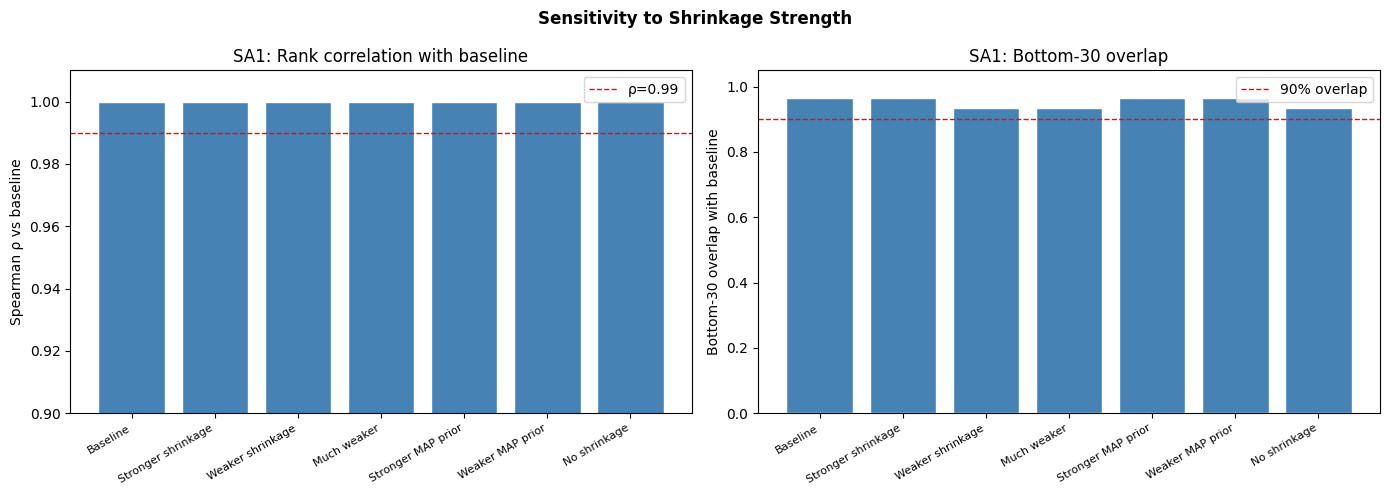


SA3: Sensitivity to censoring threshold
  Baseline: censored if log(wage_ratio) <= 0  (wage_ratio <= 1.0)
  Fitting: Strict: cens if ratio < 0.98 (cens_rate=0.000) ... done
  Strict: cens if ratio < 0.98                   rho=0.9849  bottom-30 overlap=0.27  max_rank_shift=1030
  Fitting: Baseline: cens if ratio <= 1.00 (cens_rate=0.162) ... done
  Baseline: cens if ratio <= 1.00                rho=1.0000  bottom-30 overlap=0.97  max_rank_shift=11
  Fitting: Fuzzy: cens if ratio <= 1.01 (cens_rate=0.236) ... done
  Fuzzy: cens if ratio <= 1.01                   rho=0.9865  bottom-30 overlap=0.63  max_rank_shift=1208
  Fitting: Fuzzy: cens if ratio <= 1.02 (cens_rate=0.258) ... 

KeyboardInterrupt: 

In [3]:
#Sensitivity analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import copy, warnings
warnings.filterwarnings("ignore")

EPS = 1e-6
MAX_VAL = 1e6


# ── Helpers ───────────────────────────────────────────────────────────────────

def get_employer_map(df):
    cat = pd.Categorical(df["EMPLOYER_NAME_CLEAN"])
    return dict(enumerate(cat.categories))


def spearman(a, b):
    return stats.spearmanr(a, b).statistic


def bottom_n_overlap(alpha1, alpha2, n=30):
    """Fraction of bottom-n employers shared between two alpha vectors."""
    bot1 = set(np.argsort(alpha1)[:n])
    bot2 = set(np.argsort(alpha2)[:n])
    return len(bot1 & bot2) / n


def summarise_comparison(label, alpha_base, alpha_alt, n=30):
    rho    = spearman(alpha_base, alpha_alt)
    ovlp   = bottom_n_overlap(alpha_base, alpha_alt, n=n)
    max_sh = np.max(np.abs(
        pd.Series(alpha_base).rank() - pd.Series(alpha_alt).rank()
    ))
    print(f"  {label:45s}  rho={rho:.4f}  bottom-{n} overlap={ovlp:.2f}  max_rank_shift={max_sh:.0f}")
    return {"label": label, "spearman": rho,
            f"bottom{n}_overlap": ovlp, "max_rank_shift": max_sh}


# ── Modified fit_model that accepts hyperparameter overrides ──────────────────

def fit_model_custom(data, max_iter=20,
                     sigma_E2_init=0.1,
                     sigma_L2_init=0.1,
                     sigma_S2_init=0.1,
                     sigma_ST2_init=0.1,
                     warmup_iters=10,
                     damp_w=0.1,
                     prior_a=0.1,   # numerator add-on in update_sigma
                     prior_b=2,     # denominator add-on in update_sigma
                     verbose=False):
    """
    Clone of fit_model with exposed hyperparameters.
    prior_a, prior_b implement  sigma^2 = (sum alpha^2 + prior_a) / (n + prior_b)
    which corresponds to an InvGamma(prior_b/2, prior_a/2) MAP prior.
    """
    from scipy import stats as _stats

    y, censored = data['y'], data['censored']
    L, E, S, ST = data['L'], data['E'], data['S'], data['ST']

    gamma = np.zeros(data['K'])
    alpha = np.zeros(data['N_E'])
    delta = np.zeros(data['N_S'])
    eta   = np.zeros(data['N_ST'])
    beta0 = np.mean(y)

    sigma2    = 1.0
    sigma_E2  = sigma_E2_init
    sigma_L2  = sigma_L2_init
    sigma_S2  = sigma_S2_init
    sigma_ST2 = sigma_ST2_init

    def _update_sigma(v):
        return max((np.sum(v**2) + prior_a) / (len(v) + prior_b), 1e-4)

    def _update_sigma2(r2):
        return max((np.sum(r2) + prior_a) / (len(r2) + prior_b), 1e-4)

    def _damp(old, new):
        return (1 - damp_w) * old + damp_w * new

    def _trunc_moments(mu, sigma):
        sigma = np.maximum(sigma, EPS)
        a_    = np.clip(-mu / sigma, -10, 10)
        phi   = _stats.norm.pdf(a_)
        Phi   = np.clip(_stats.norm.cdf(a_), 1e-10, 1.0)
        ratio = np.clip(phi / Phi, -MAX_VAL, MAX_VAL)
        E1    = mu - sigma * ratio
        E2    = mu**2 + sigma**2 - sigma * (mu + sigma * ratio) * ratio
        return E1, E2

    lls = []
    for it in range(max_iter):
        mu = beta0 + gamma[L] + alpha[E] + delta[S] + eta[ST]

        # E-step
        y_star  = y.copy(); y_star2 = y**2
        if censored.any():
            E1, E2 = _trunc_moments(mu[censored], np.sqrt(sigma2))
            y_star[censored]  = E1
            y_star2[censored] = E2

        # M-step
        n   = len(y_star)
        lam_E  = min(sigma2 / sigma_E2,  MAX_VAL)
        lam_L  = min(sigma2 / sigma_L2,  MAX_VAL)
        lam_S  = min(sigma2 / sigma_S2,  MAX_VAL)
        lam_ST = min(sigma2 / sigma_ST2, MAX_VAL)
        n_L  = np.bincount(L, minlength=data['K'])
        n_E  = np.bincount(E, minlength=data['N_E'])
        n_S  = np.bincount(S, minlength=data['N_S'])
        n_ST = np.bincount(ST, minlength=data['N_ST'])
        Sy_L  = np.bincount(L,  weights=y_star, minlength=data['K'])
        Sy_E  = np.bincount(E,  weights=y_star, minlength=data['N_E'])
        Sy_S  = np.bincount(S,  weights=y_star, minlength=data['N_S'])
        Sy_ST = np.bincount(ST, weights=y_star, minlength=data['N_ST'])
        Sy_total = y_star.sum()

        for _ in range(30):
            beta0 = (Sy_total - (gamma[L]+alpha[E]+delta[S]+eta[ST]).sum()) / n
            gamma = (Sy_L  - np.bincount(L,  weights=alpha[E]+delta[S]+eta[ST], minlength=data['K'])   - n_L*beta0)  / (n_L  + lam_L)
            alpha = (Sy_E  - np.bincount(E,  weights=gamma[L]+delta[S]+eta[ST], minlength=data['N_E'])  - n_E*beta0)  / (n_E  + lam_E)
            delta = (Sy_S  - np.bincount(S,  weights=gamma[L]+alpha[E]+eta[ST], minlength=data['N_S'])  - n_S*beta0)  / (n_S  + lam_S)
            eta   = (Sy_ST - np.bincount(ST, weights=gamma[L]+alpha[E]+delta[S],minlength=data['N_ST']) - n_ST*beta0) / (n_ST + lam_ST)

        mu = beta0 + gamma[L] + alpha[E] + delta[S] + eta[ST]
        resid2 = np.clip(y_star2 - 2*y_star*mu + mu**2, 0, MAX_VAL)
        sigma2 = _update_sigma2(resid2)

        if it < warmup_iters:
            sigma_E2  = _damp(sigma_E2,  _update_sigma(alpha))
            sigma_L2  = _damp(sigma_L2,  _update_sigma(gamma))
            sigma_S2  = _damp(sigma_S2,  _update_sigma(delta))
            sigma_ST2 = _damp(sigma_ST2, _update_sigma(eta))

        ll = 0
        if (~censored).any():
            ll += _stats.norm.logpdf(y[~censored], mu[~censored], np.sqrt(sigma2)).sum()
        if censored.any():
            ll += np.log(np.clip(_stats.norm.cdf(0, mu[censored], np.sqrt(sigma2)), 1e-10, 1)).sum()
        lls.append(ll)

        if verbose:
            print(f"  iter {it}: ll={ll:.2f}  sigma_E={np.sqrt(sigma_E2):.4f}")
        if it > 2 and abs(lls[-1] - lls[-2]) < 1:
            break

    return {"beta0": beta0, "gamma": gamma, "alpha": alpha,
            "delta": delta, "eta": eta, "sigma": np.sqrt(sigma2),
            "sigma_E": np.sqrt(sigma_E2), "lls": lls, "data": data}


# ── SA1: Shrinkage strength ───────────────────────────────────────────────────

def sa1_shrinkage(result_base, data, n_bottom=30):
    """
    Vary sigma_E2 initial value and the MAP prior strength.
    Key question: do the bottom-N employer rankings change?
    """
    print("\n" + "="*70)
    print("SA1: Sensitivity to shrinkage strength")
    print("="*70)
    print(f"  Baseline: sigma_E2_init=0.1, prior_a=0.1, prior_b=2")
    print(f"  (These set the initial penalty lambda_E = sigma2/sigma_E2)\n")

    alpha_base = result_base["alpha"]
    configs = [
        # label,                    sigma_E2_init, prior_a, prior_b
        ("Baseline (sigma_E2=0.1, weak prior)",    0.10,  0.1, 2),
        ("Stronger shrinkage (sigma_E2=0.01)",     0.01,  0.1, 2),
        ("Weaker shrinkage (sigma_E2=1.0)",        1.00,  0.1, 2),
        ("Much weaker (sigma_E2=5.0)",             5.00,  0.1, 2),
        ("Stronger MAP prior (a=1, b=5)",          0.10,  1.0, 5),
        ("Weaker MAP prior (a=0.01, b=0.5)",       0.10, 0.01, 0.5),
        ("No shrinkage (sigma_E2=100)",           100.0,  0.1, 2),
    ]

    results_sa1 = []
    rows = []
    for label, s_init, pa, pb in configs:
        print(f"  Fitting: {label} ...", end=" ", flush=True)
        r = fit_model_custom(data, sigma_E2_init=s_init,
                              prior_a=pa, prior_b=pb)
        print(f"sigma_E={r['sigma_E']:.4f}")
        row = summarise_comparison(label, alpha_base, r["alpha"], n=n_bottom)
        row["sigma_E_final"] = r["sigma_E"]
        rows.append(row)
        results_sa1.append((label, r))

    # Plot: rank correlation and bottom-N overlap across configs
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    labels_short = [c[0].split("(")[0].strip() for c in configs]
    rhos   = [row["spearman"]            for row in rows]
    ovlps  = [row[f"bottom{n_bottom}_overlap"] for row in rows]
    sigmas = [row["sigma_E_final"]       for row in rows]

    x = np.arange(len(configs))
    axes[0].bar(x, rhos, color="steelblue", edgecolor="white")
    axes[0].axhline(0.99, color="red", ls="--", lw=1, label="ρ=0.99")
    axes[0].set_xticks(x); axes[0].set_xticklabels(labels_short,
                                                     rotation=30, ha="right", fontsize=8)
    axes[0].set_ylabel("Spearman ρ vs baseline"); axes[0].set_ylim(0.9, 1.01)
    axes[0].set_title("SA1: Rank correlation with baseline")
    axes[0].legend()

    axes[1].bar(x, ovlps, color="steelblue", edgecolor="white")
    axes[1].axhline(0.9, color="red", ls="--", lw=1, label="90% overlap")
    axes[1].set_xticks(x); axes[1].set_xticklabels(labels_short,
                                                     rotation=30, ha="right", fontsize=8)
    axes[1].set_ylabel(f"Bottom-{n_bottom} overlap with baseline")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title(f"SA1: Bottom-{n_bottom} overlap")
    axes[1].legend()

    plt.suptitle("Sensitivity to Shrinkage Strength", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("figures/sa1_shrinkage.png", dpi=150, bbox_inches="tight")
    plt.show()
    return pd.DataFrame(rows)


# ── SA2: Warmup length ────────────────────────────────────────────────────────

def sa2_warmup(result_base, data, n_bottom=30):
    """
    Vary the number of EM iterations before variance params are frozen.
    Key question: does freezing too early / too late change employer rankings?
    """
    print("\n" + "="*70)
    print("SA2: Sensitivity to warmup length (baseline = 10 iterations)")
    print("="*70)

    alpha_base = result_base["alpha"]
    warmup_vals = [1, 5, 10, 20, 50]  # 50 = never freeze (fully adaptive)
    rows = []
    sigma_E_finals = []

    for w in warmup_vals:
        label = f"warmup={w}" if w < 50 else "warmup=50 (never freeze)"
        print(f"  Fitting: {label} ...", end=" ", flush=True)
        r = fit_model_custom(data, warmup_iters=w)
        print(f"sigma_E={r['sigma_E']:.4f}")
        row = summarise_comparison(label, alpha_base, r["alpha"], n=n_bottom)
        row["sigma_E_final"] = r["sigma_E"]
        rows.append(row)
        sigma_E_finals.append(r["sigma_E"])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    x = warmup_vals
    axes[0].plot(x, [row["spearman"] for row in rows], "o-", color="steelblue")
    axes[0].axhline(0.99, color="red", ls="--", lw=1)
    axes[0].set_xlabel("Warmup iterations"); axes[0].set_ylabel("Spearman ρ vs baseline")
    axes[0].set_title("SA2a: Rank correlation")

    axes[1].plot(x, sigma_E_finals, "o-", color="steelblue")
    axes[1].axhline(result_base["sigma_E"], color="red", ls="--", lw=1,
                    label=f"baseline σ_E={result_base['sigma_E']:.4f}")
    axes[1].set_xlabel("Warmup iterations"); axes[1].set_ylabel("Final σ_E")
    axes[1].set_title("SA2b: Final sigma_E vs warmup length")
    axes[1].legend()

    plt.suptitle("Sensitivity to Warmup Length", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("figures/sa2_warmup.png", dpi=150, bbox_inches="tight")
    plt.show()
    return pd.DataFrame(rows)


# ── SA3: Censoring threshold ──────────────────────────────────────────────────

def sa3_censoring_threshold(df_raw, result_base, n_bottom=30):
    """
    The baseline defines censored = (log wage_ratio <= 0), i.e. wage <= prevailing.
    In practice wage_ratio values very close to 1.0 might reflect rounding
    or minor reporting errors rather than genuine bunching.
    Test: what if we use a strict (< 0.99) or fuzzy (< 1.02) threshold?
    Key question: do conclusions about worst employers change?
    """
    print("\n" + "="*70)
    print("SA3: Sensitivity to censoring threshold")
    print("="*70)
    print("  Baseline: censored if log(wage_ratio) <= 0  (wage_ratio <= 1.0)")

    alpha_base = result_base["alpha"]
    rows = []

    thresholds = [
        ("Strict: cens if ratio < 0.98",  0.98),
        ("Baseline: cens if ratio <= 1.00", 1.00),
        ("Fuzzy: cens if ratio <= 1.01",   1.01),
        ("Fuzzy: cens if ratio <= 1.02",   1.02),
        ("Fuzzy: cens if ratio <= 1.05",   1.05),
    ]

    cens_rates = []
    for label, thresh in thresholds:
        df_t = df_raw.copy()

        # Recompute y and censored with new threshold
        df_t["SOC_2DIGIT"] = df_t["SOC_CODE"].astype(str).str[:2]
        soc_counts = df_t["SOC_2DIGIT"].value_counts()
        df_t["SOC_F"] = df_t["SOC_2DIGIT"].where(
            df_t["SOC_2DIGIT"].isin(soc_counts[soc_counts >= 100].index), "OTHER")
        state_counts = df_t["WORKSITE_STATE"].value_counts()
        df_t["STATE_F"] = df_t["WORKSITE_STATE"].where(
            df_t["WORKSITE_STATE"].isin(state_counts[state_counts >= 100].index), "OTHER")

        import pandas as _pd
        S   = _pd.Categorical(df_t["SOC_F"]).codes
        ST  = _pd.Categorical(df_t["STATE_F"]).codes
        E   = _pd.Categorical(df_t["EMPLOYER_NAME_CLEAN"]).codes
        level_map = {"I":0,"II":1,"III":2,"IV":3}
        L   = df_t["WAGE_LEVEL_CLEAN"].map(level_map).values

        log_ratio = np.log(df_t["wage_ratio"].values)
        y_t       = np.maximum(log_ratio, 0.0)
        # new censoring definition
        censored_t = df_t["wage_ratio"].values <= thresh

        data_t = {
            "y": y_t, "censored": censored_t,
            "L": L, "E": E, "S": S, "ST": ST,
            "K": 4,
            "N_E": len(np.unique(E)),
            "N_S": len(np.unique(S)),
            "N_ST": len(np.unique(ST)),
        }

        cens_rate = censored_t.mean()
        cens_rates.append(cens_rate)
        print(f"  Fitting: {label} (cens_rate={cens_rate:.3f}) ...",
              end=" ", flush=True)
        r = fit_model_custom(data_t)
        print(f"done")

        # align alpha vectors (same employer encoding assumed)
        n_shared = min(len(alpha_base), len(r["alpha"]))
        row = summarise_comparison(label,
                                   alpha_base[:n_shared],
                                   r["alpha"][:n_shared], n=n_bottom)
        row["cens_rate"] = cens_rate
        rows.append(row)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    labels_short = [t[0] for t in thresholds]
    x = np.arange(len(thresholds))

    axes[0].bar(x, [row["spearman"] for row in rows],
                color="steelblue", edgecolor="white")
    axes[0].axhline(0.99, color="red", ls="--", lw=1)
    axes[0].set_xticks(x); axes[0].set_xticklabels(labels_short,
                                                     rotation=20, ha="right", fontsize=8)
    axes[0].set_ylabel("Spearman ρ vs baseline"); axes[0].set_ylim(0.9, 1.01)
    axes[0].set_title("SA3a: Rank correlation")

    axes[1].bar(x, cens_rates, color="steelblue", edgecolor="white")
    axes[1].set_xticks(x); axes[1].set_xticklabels(labels_short,
                                                     rotation=20, ha="right", fontsize=8)
    axes[1].set_ylabel("Fraction censored")
    axes[1].set_title("SA3b: Censoring rate under each threshold")

    plt.suptitle("Sensitivity to Censoring Threshold Definition",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("figures/sa3_censoring.png", dpi=150, bbox_inches="tight")
    plt.show()
    return pd.DataFrame(rows)


# ── SA4: Employer size cutoff ─────────────────────────────────────────────────

def sa4_size_cutoff(df_raw, result_base, n_bottom=30):
    """
    Baseline includes employers with >= 100 applications.
    Test: does changing this cutoff change which employers are flagged?
    Smaller cutoff = more employers included but noisier estimates.
    """
    print("\n" + "="*70)
    print("SA4: Sensitivity to employer size cutoff (baseline >= 100)")
    print("="*70)

    alpha_base = result_base["alpha"]
    cutoffs = [50, 100, 200, 500]
    rows = []

    for cut in cutoffs:
        df_t = df_raw[df_raw["EMPLOYER_NAME_CLEAN"].map(
            df_raw["EMPLOYER_NAME_CLEAN"].value_counts()) >= cut].copy()

        df_t["SOC_2DIGIT"] = df_t["SOC_CODE"].astype(str).str[:2]
        soc_counts = df_t["SOC_2DIGIT"].value_counts()
        df_t["SOC_F"] = df_t["SOC_2DIGIT"].where(
            df_t["SOC_2DIGIT"].isin(soc_counts[soc_counts >= 100].index), "OTHER")
        state_counts = df_t["WORKSITE_STATE"].value_counts()
        df_t["STATE_F"] = df_t["WORKSITE_STATE"].where(
            df_t["WORKSITE_STATE"].isin(state_counts[state_counts >= 100].index), "OTHER")

        import pandas as _pd
        S   = _pd.Categorical(df_t["SOC_F"]).codes
        ST  = _pd.Categorical(df_t["STATE_F"]).codes
        E   = _pd.Categorical(df_t["EMPLOYER_NAME_CLEAN"]).codes
        level_map = {"I":0,"II":1,"III":2,"IV":3}
        L   = df_t["WAGE_LEVEL_CLEAN"].map(level_map).values
        y_t = np.maximum(np.log(df_t["wage_ratio"].values), 0.0)
        censored_t = y_t == 0.0

        data_t = {"y":y_t,"censored":censored_t,"L":L,"E":E,"S":S,"ST":ST,
                  "K":4,"N_E":len(np.unique(E)),"N_S":len(np.unique(S)),
                  "N_ST":len(np.unique(ST))}

        label = f"cutoff >= {cut}  (n_emp={data_t['N_E']})"
        print(f"  Fitting: {label} ...", end=" ", flush=True)
        r = fit_model_custom(data_t)
        print("done")

        # match employers present in both
        base_emps = set(pd.Categorical(
            df_raw[df_raw["EMPLOYER_NAME_CLEAN"].map(
                df_raw["EMPLOYER_NAME_CLEAN"].value_counts()) >= 100
            ]["EMPLOYER_NAME_CLEAN"]).categories)
        alt_emps  = set(pd.Categorical(df_t["EMPLOYER_NAME_CLEAN"]).categories)
        shared    = sorted(base_emps & alt_emps)

        base_cat = pd.Categorical(
            df_raw[df_raw["EMPLOYER_NAME_CLEAN"].map(
                df_raw["EMPLOYER_NAME_CLEAN"].value_counts()) >= 100
            ]["EMPLOYER_NAME_CLEAN"]).categories
        alt_cat  = pd.Categorical(df_t["EMPLOYER_NAME_CLEAN"]).categories

        a_base_sh = np.array([alpha_base[list(base_cat).index(e)]
                               for e in shared if e in list(base_cat)])
        a_alt_sh  = np.array([r["alpha"][list(alt_cat).index(e)]
                               for e in shared if e in list(alt_cat)])

        n_use = min(len(a_base_sh), len(a_alt_sh))
        row = summarise_comparison(label, a_base_sh[:n_use],
                                   a_alt_sh[:n_use], n=min(n_bottom, n_use))
        row["n_employers"] = data_t["N_E"]
        rows.append(row)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(cutoffs, [row["spearman"] for row in rows], "o-", color="steelblue")
    ax.axhline(0.99, color="red", ls="--", lw=1, label="ρ=0.99")
    ax.set_xlabel("Minimum applications per employer")
    ax.set_ylabel("Spearman ρ (shared employers vs baseline)")
    ax.set_title("SA4: Sensitivity to Employer Size Cutoff")
    ax2 = ax.twinx()
    ax2.plot(cutoffs, [row["n_employers"] for row in rows],
             "s--", color="gray", alpha=0.6)
    ax2.set_ylabel("Number of employers included", color="gray")
    ax.legend()
    plt.tight_layout()
    plt.savefig("figures/sa4_size_cutoff.png", dpi=150, bbox_inches="tight")
    plt.show()
    return pd.DataFrame(rows)


# ── Summary table ─────────────────────────────────────────────────────────────

def plot_summary_table(sa1_df, sa3_df):
    """One-page summary of all sensitivity checks."""
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))

    def _bar(ax, df, title, col="spearman", ylim=(0.85, 1.01)):
        x = np.arange(len(df))
        ax.bar(x, df[col], color="steelblue", edgecolor="white")
        ax.axhline(0.99, color="red", ls="--", lw=1, label="ρ=0.99")
        ax.set_xticks(x)
        ax.set_xticklabels(
            [s[:30] for s in df["label"]], rotation=25, ha="right", fontsize=8)
        ax.set_ylabel("Spearman ρ vs baseline")
        ax.set_ylim(*ylim)
        ax.set_title(title)
        ax.legend(fontsize=8)

    _bar(axes[0,0], sa1_df, "SA1: Shrinkage strength")
    _bar(axes[1,0], sa3_df, "SA3: Censoring threshold")

    plt.suptitle("Sensitivity Analysis Summary: Spearman ρ vs Baseline",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("figures/sa_summary.png", dpi=150, bbox_inches="tight")
    plt.show()


# ── Master runner ─────────────────────────────────────────────────────────────

def run_all_sensitivity(result_baseline, data, df_raw, n_bottom=30):
    """
    Parameters
    ----------
    result_baseline : dict from fit_model()
    data            : dict from prepare_data()
    df_raw          : the filtered DataFrame passed to prepare_data()
    n_bottom        : how many bottom employers to track for overlap
    """
    import os; os.makedirs("figures", exist_ok=True)

    print("Running SA1: shrinkage ...")
    sa1 = sa1_shrinkage(result_baseline, data, n_bottom=n_bottom)

    #print("\nRunning SA2: warmup ...")
    #sa2 = sa2_warmup(result_baseline, data, n_bottom=n_bottom)

    print("\nRunning SA3: censoring threshold ...")
    sa3 = sa3_censoring_threshold(df_raw, result_baseline, n_bottom=n_bottom)

    #print("\nRunning SA4: size cutoff ...")
    #sa4 = sa4_size_cutoff(df_raw, result_baseline, n_bottom=n_bottom)

    print("\nSummary plot ...")
    plot_summary_table(sa1, sa3)

    return sa1, sa3

sa1 = sa1_shrinkage(result, data, n_bottom=30)
sa3 = sa3_censoring_threshold(df, result, n_bottom=30)

# simple two-panel summary instead of four-panel
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, df_sa, title in zip(axes, [sa1, sa3],
                             ["SA1: Shrinkage strength",
                              "SA3: Censoring threshold"]):
    x = np.arange(len(df_sa))
    ax.bar(x, df_sa["spearman"], color="steelblue", edgecolor="white")
    ax.axhline(0.99, color="red", ls="--", lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels([s[:30] for s in df_sa["label"]],
                       rotation=25, ha="right", fontsize=8)
    ax.set_ylabel("Spearman ρ vs baseline")
    ax.set_ylim(0.85, 1.01)
    ax.set_title(title)

plt.suptitle("Sensitivity Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/sa_summary.png", dpi=150, bbox_inches="tight")
plt.show()

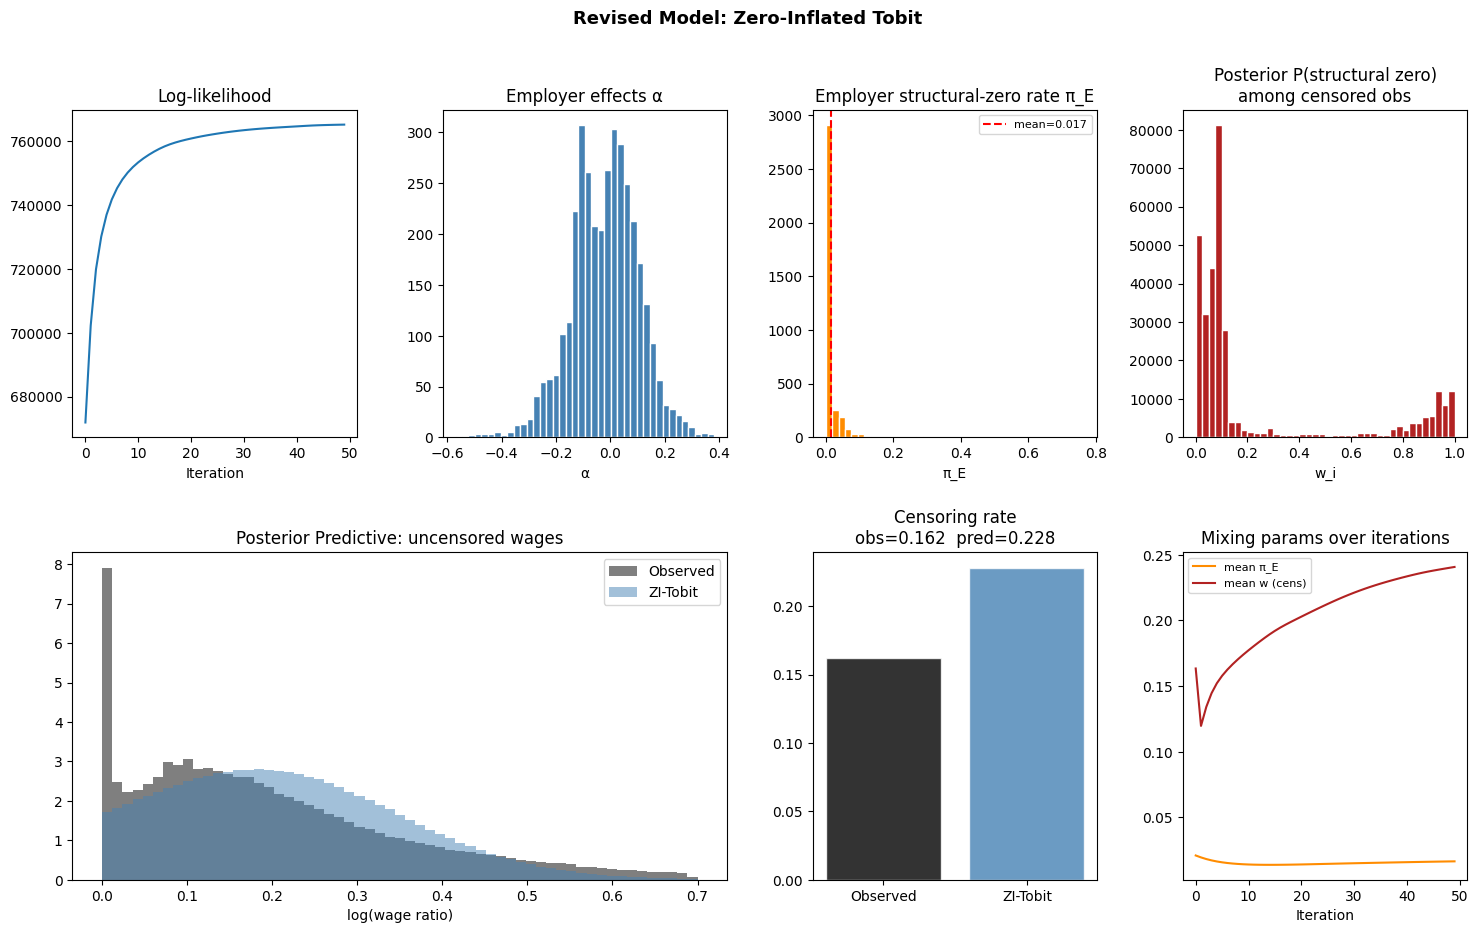

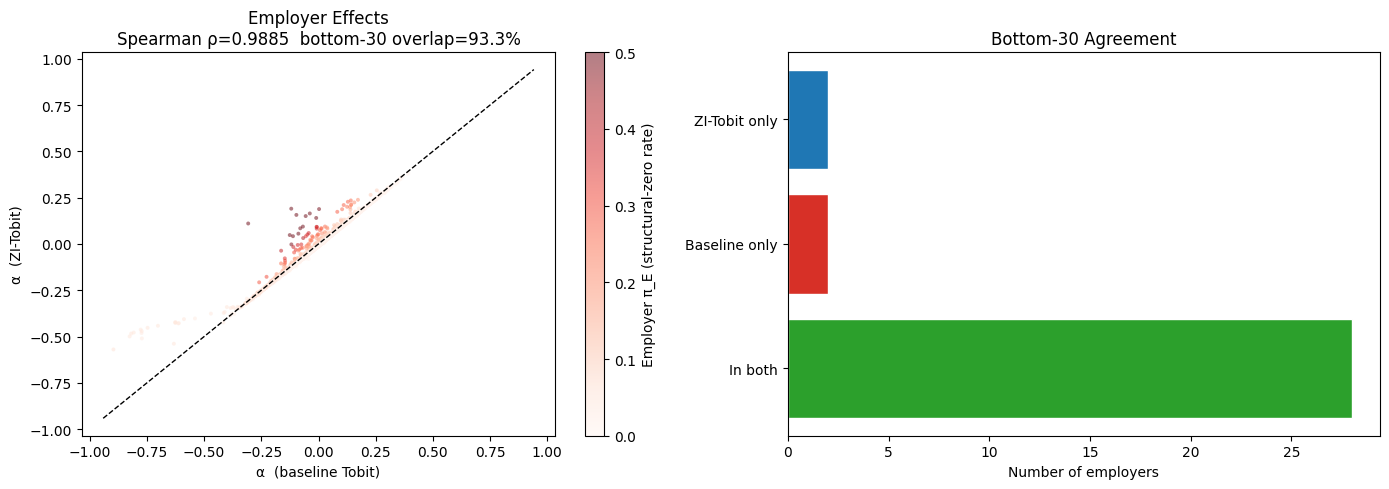

Spearman ρ: 0.9885  |  bottom-30 overlap: 93.3%

Flagged by BASELINE only (2):
  samsara
  spirent communications

Flagged by ZI-TOBIT only (2):
  logic loops
  safe code soft technologies
CHECK 1: Global distribution ...


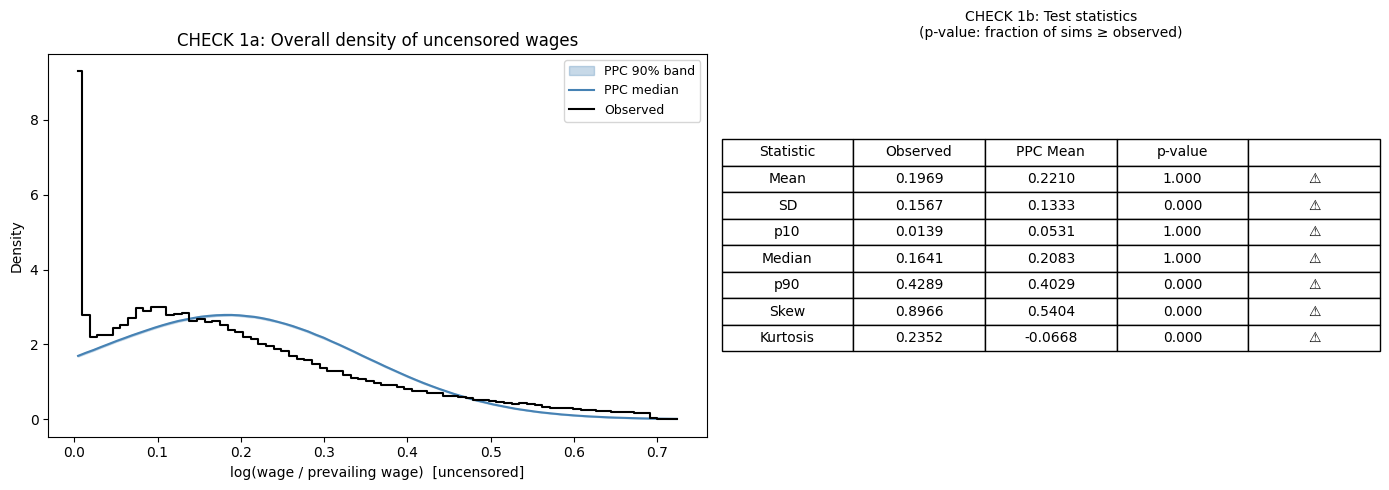

CHECK 2: Censoring rates ...


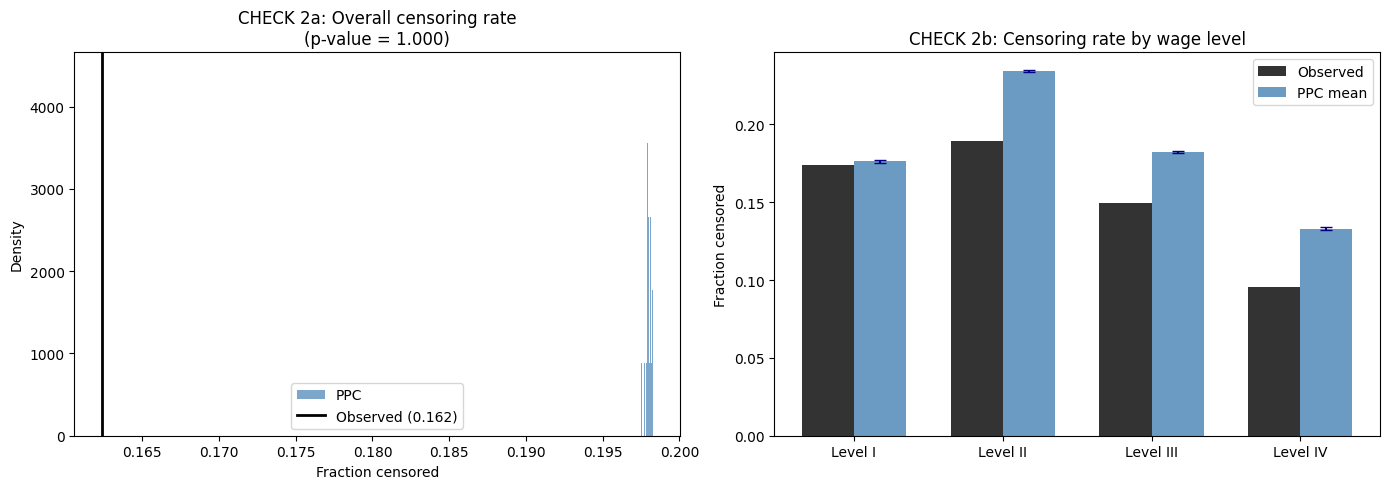

Observed censoring by level: {'I': np.float64(0.174), 'II': np.float64(0.189), 'III': np.float64(0.149), 'IV': np.float64(0.096)}
PPC mean censoring by level: {'I': np.float64(0.176), 'II': np.float64(0.234), 'III': np.float64(0.182), 'IV': np.float64(0.133)}
CHECK 3: Distribution by wage level ...


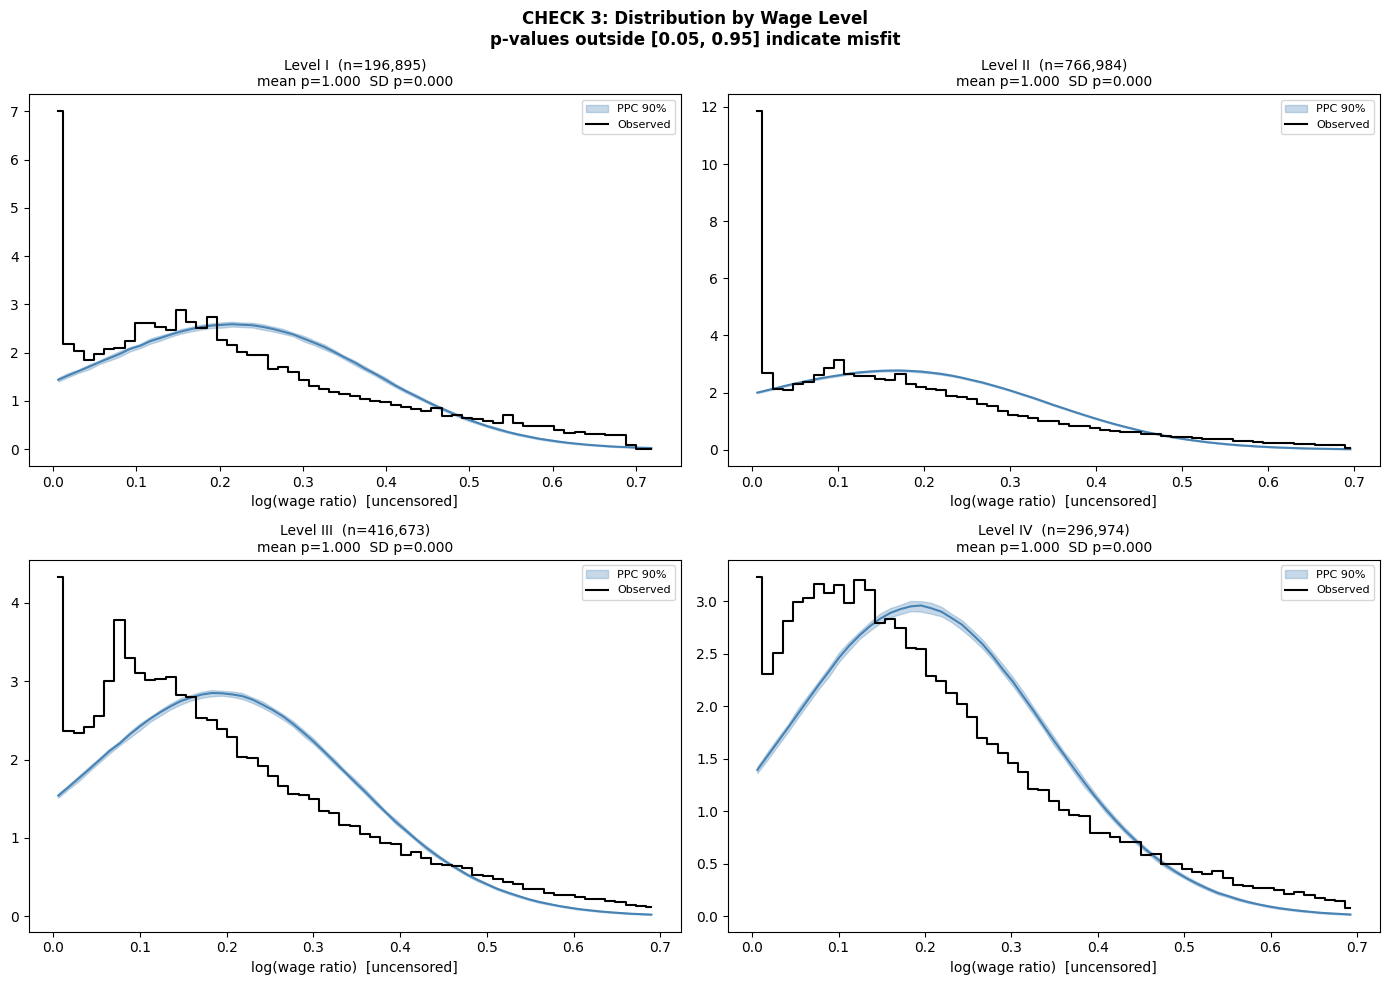

CHECK 4: Employer-level censoring calibration ...


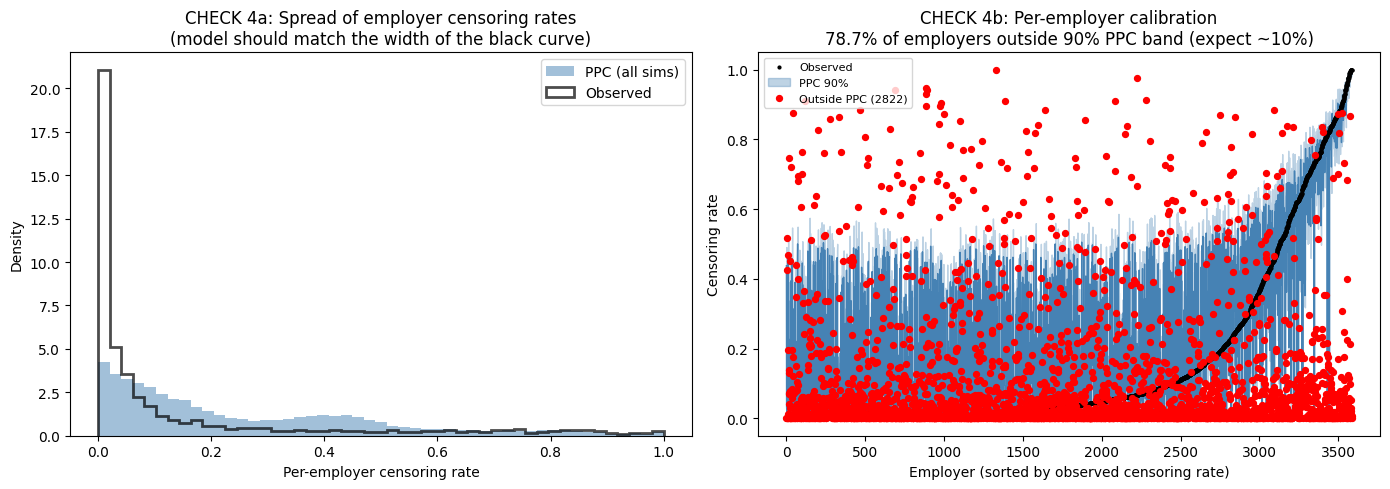

CHECK 5: Residual diagnostics ...


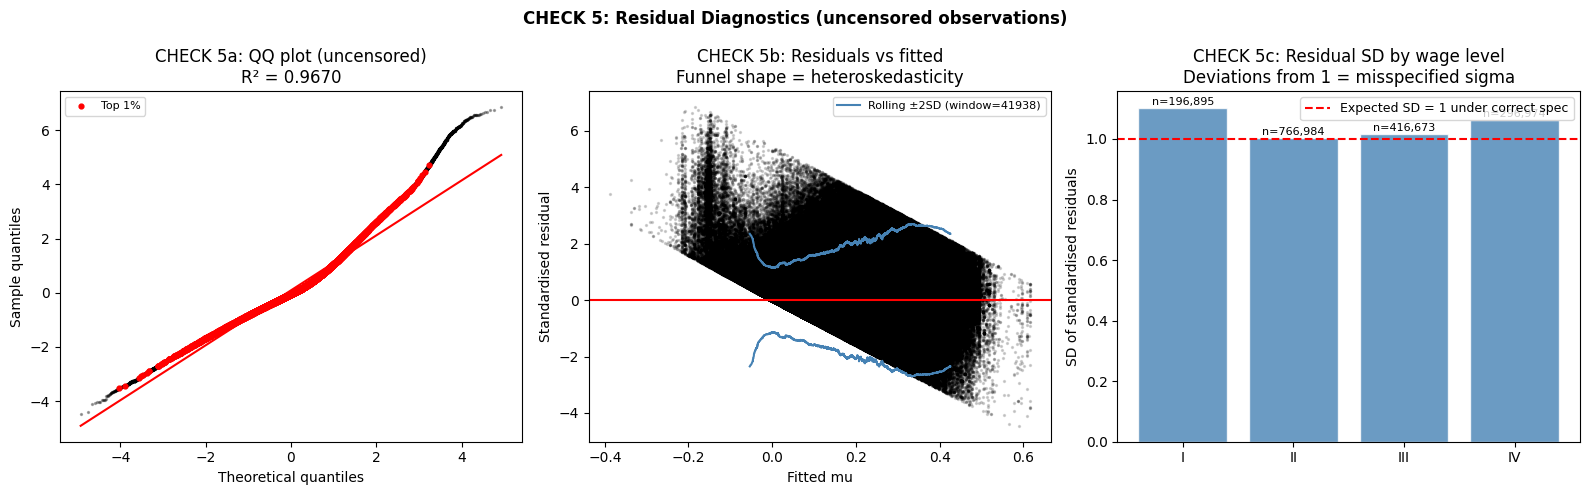

CHECK 6: Top-flagged employer deep-dives ...


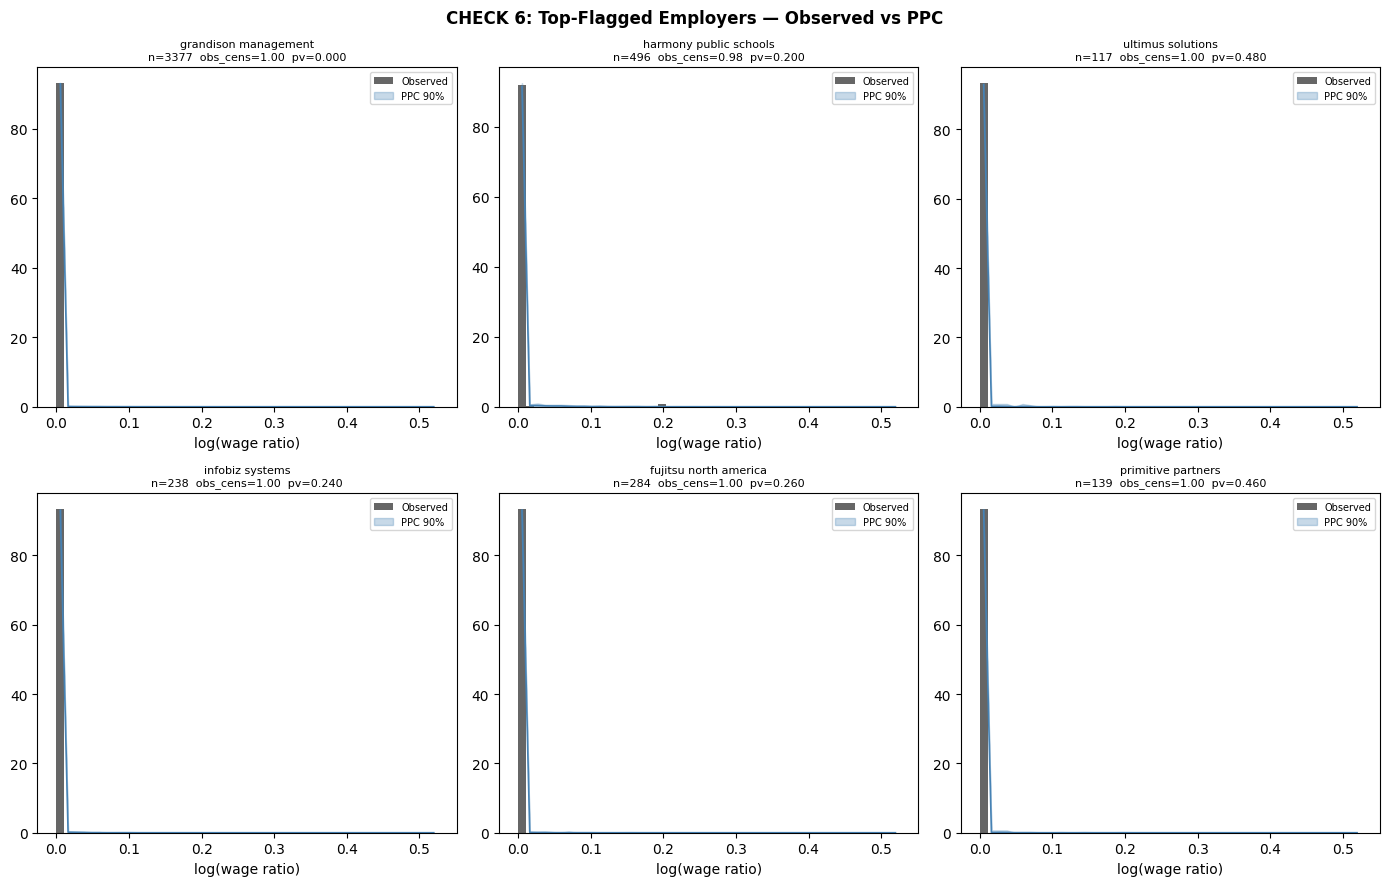

Done. Figures saved to figures/ppc_*.png


In [6]:
"""
Revised Model: Zero-Inflated Tobit (ZI-Tobit)
===============================================
Motivation from PPCs:
  - Check 2: model overcounts censoring by ~30% (predicts 21%, observed 16%)
  - Check 4: 77.6% of employers outside 90% PPC band for censoring rate

Root cause: standard Tobit attributes ALL zeros to censoring (employer
wanted to pay below prevailing but couldn't). In reality some zeros are
STRATEGIC: employers deliberately target the prevailing wage exactly.

Fix: introduce a latent indicator z_i in {0,1} per observation:
  z_i = 1  (structural zero): employer targets threshold -> y_i = 0 always
  z_i = 0  (Tobit):           y_i* ~ N(mu_i, sigma^2), y_i = max(y_i*, 0)

Employer-specific structural-zero rate:
  pi_E[e] = P(z_i=1) for employer e, shrunk toward global rate via
  empirical Bayes prior, capped at employer's observed censoring fraction
  (since uncensored obs cannot be structural zeros).

EM:
  E-step: w_i = P(z_i=1 | y_i=0) for censored obs, 0 for uncensored
  M-step: down-weight censored obs by (1-w_i); update pi_E stably
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

EPS     = 1e-8
MAX_VAL = 1e6


# =============================================================================
# DATA PREP  (unchanged from model2)
# =============================================================================

def prepare_data(df):
    df = df.copy()
    df["SOC_2DIGIT"] = df["SOC_CODE"].astype(str).str[:2]
    soc_counts = df["SOC_2DIGIT"].value_counts()
    df["SOC_F"] = df["SOC_2DIGIT"].where(
        df["SOC_2DIGIT"].isin(soc_counts[soc_counts >= 100].index), "OTHER")
    state_counts = df["WORKSITE_STATE"].value_counts()
    df["STATE_F"] = df["WORKSITE_STATE"].where(
        df["WORKSITE_STATE"].isin(state_counts[state_counts >= 100].index), "OTHER")
    S  = pd.Categorical(df["SOC_F"]).codes
    ST = pd.Categorical(df["STATE_F"]).codes
    E  = pd.Categorical(df["EMPLOYER_NAME_CLEAN"]).codes
    level_map = {"I":0,"II":1,"III":2,"IV":3}
    L  = df["WAGE_LEVEL_CLEAN"].map(level_map).values
    y  = np.maximum(np.log(df["wage_ratio"].values), 0)
    censored = (y == 0)
    return {
        "y": y, "censored": censored,
        "L": L, "E": E, "S": S, "ST": ST,
        "K": 4,
        "N_E":  len(np.unique(E)),
        "N_S":  len(np.unique(S)),
        "N_ST": len(np.unique(ST)),
    }


# =============================================================================
# TRUNCATED NORMAL MOMENTS  (unchanged from model2)
# =============================================================================

def truncated_normal_moments(mu, sigma):
    sigma = np.maximum(sigma, EPS)
    a     = np.clip(-mu / sigma, -10, 10)
    phi   = stats.norm.pdf(a)
    Phi   = np.clip(stats.norm.cdf(a), EPS, 1.0)
    ratio = np.clip(phi / Phi, -MAX_VAL, MAX_VAL)
    E1    = mu - sigma * ratio
    E2    = mu**2 + sigma**2 - sigma*(mu + sigma*ratio)*ratio
    return E1, E2


# =============================================================================
# E-STEP
# =============================================================================

def e_step(y, censored, mu, sigma, pi_E, E):
    """
    For uncensored obs: w_i = 0  (cannot be structural zero).
    For censored obs:
        P(y=0 | z=0) = Phi(-mu/sigma)   [Tobit censoring prob]
        w_i = pi_E[e] / (pi_E[e] + (1-pi_E[e]) * Phi(-mu/sigma))

    y_star for censored obs: truncated normal imputation (for Tobit component).
    In the M-step this is down-weighted by (1-w_i).
    """
    n      = len(y)
    w      = np.zeros(n)
    y_star  = y.copy()
    y_star2 = y**2

    if censored.any():
        mu_c    = mu[censored]
        pi_c    = pi_E[E[censored]]
        sigma_c = max(sigma, EPS)
        Phi_c   = np.clip(stats.norm.cdf(-mu_c / sigma_c), EPS, 1.0)
        denom   = pi_c + (1.0 - pi_c) * Phi_c
        w_c     = np.clip(pi_c / denom, 0.0, 1.0)
        w[censored] = w_c

        E1, E2 = truncated_normal_moments(mu_c, sigma_c)
        y_star[censored]  = E1
        y_star2[censored] = E2

    return w, y_star, y_star2


# =============================================================================
# M-STEP
# =============================================================================

def m_step(y_star, y_star2, w, censored, L, E, S, ST,
           gamma, alpha, delta, eta,
           pi_E, sigma2, sigma_E2, sigma_L2, sigma_S2, sigma_ST2,
           pi_prior_strength=10.0):
    """
    tobit_w_i = (1 - w_i): effective weight for Tobit component.
    Structural zeros (w_i ~ 1) are down-weighted so they don't
    pull mu_i downward or inflate sigma.

    pi_E update: empirical Bayes with prior centered at global rate.
    CRITICAL STABILITY CONSTRAINT: pi_E[e] cannot exceed the fraction
    of censored observations for employer e. An uncensored obs can never
    be a structural zero, so pi_E > cens_rate[e] would give log(1-pi_E) -> -inf
    for uncensored obs, crashing the LL.
    """
    tobit_w = 1.0 - w

    lam_L  = min(sigma2 / sigma_L2,  MAX_VAL)
    lam_E  = min(sigma2 / sigma_E2,  MAX_VAL)
    lam_S  = min(sigma2 / sigma_S2,  MAX_VAL)
    lam_ST = min(sigma2 / sigma_ST2, MAX_VAL)
    K    = len(gamma);     N_E = len(alpha)
    N_S  = len(delta);     N_ST = len(eta)

    Sw_L   = np.bincount(L,  weights=tobit_w, minlength=K)
    Sw_E   = np.bincount(E,  weights=tobit_w, minlength=N_E)
    Sw_S   = np.bincount(S,  weights=tobit_w, minlength=N_S)
    Sw_ST  = np.bincount(ST, weights=tobit_w, minlength=N_ST)
    Swy_L  = np.bincount(L,  weights=tobit_w*y_star, minlength=K)
    Swy_E  = np.bincount(E,  weights=tobit_w*y_star, minlength=N_E)
    Swy_S  = np.bincount(S,  weights=tobit_w*y_star, minlength=N_S)
    Swy_ST = np.bincount(ST, weights=tobit_w*y_star, minlength=N_ST)
    Swy_tot = (tobit_w * y_star).sum()
    Sw_tot  = tobit_w.sum()

    # ── location params ───────────────────────────────────────────────────────
    for _ in range(30):
        beta0 = (Swy_tot
                 - (tobit_w*(gamma[L]+alpha[E]+delta[S]+eta[ST])).sum()
                 ) / (Sw_tot + EPS)
        gamma = (Swy_L  - np.bincount(L,  weights=tobit_w*(alpha[E]+delta[S]+eta[ST]),  minlength=K)   - Sw_L*beta0) / (Sw_L  + lam_L  + EPS)
        alpha = (Swy_E  - np.bincount(E,  weights=tobit_w*(gamma[L]+delta[S]+eta[ST]),  minlength=N_E) - Sw_E*beta0) / (Sw_E  + lam_E  + EPS)
        delta = (Swy_S  - np.bincount(S,  weights=tobit_w*(gamma[L]+alpha[E]+eta[ST]),  minlength=N_S) - Sw_S*beta0) / (Sw_S  + lam_S  + EPS)
        eta   = (Swy_ST - np.bincount(ST, weights=tobit_w*(gamma[L]+alpha[E]+delta[S]), minlength=N_ST)- Sw_ST*beta0) / (Sw_ST + lam_ST + EPS)

    mu = beta0 + gamma[L] + alpha[E] + delta[S] + eta[ST]

    # ── sigma^2 (weighted) ────────────────────────────────────────────────────
    wresid2 = tobit_w * np.clip(y_star2 - 2*y_star*mu + mu**2, 0, MAX_VAL)
    sigma2_new = max((wresid2.sum() + 0.1) / (Sw_tot + 2), 1e-4)

    # ── pi_E update (stable empirical Bayes) ──────────────────────────────────
    # Prior center = previous pi_E mean (NOT w.mean() -- that causes feedback loop)
    global_pi = np.clip(pi_E.mean(), EPS, 1.0 - EPS)

    n_E_cnt  = np.bincount(E, minlength=N_E).astype(float)
    sw_E     = np.bincount(E, weights=w, minlength=N_E)

    # Hard cap: pi_E[e] <= fraction of censored obs for employer e
    # Uncensored obs CANNOT be structural zeros -> log(1-pi_E) -> -inf otherwise
    n_cens_E = np.bincount(E, weights=censored.astype(float), minlength=N_E)
    max_pi_E = np.clip(n_cens_E / np.maximum(n_E_cnt, 1), EPS, 1.0 - EPS)

    prior_a  = global_pi       * pi_prior_strength
    prior_b  = (1 - global_pi) * pi_prior_strength
    pi_E_raw = (sw_E + prior_a) / (n_E_cnt + prior_a + prior_b)
    pi_E_new = np.minimum(pi_E_raw, max_pi_E)
    pi_E_new = np.clip(pi_E_new, EPS, 1.0 - EPS)

    # Damp: take only 20% of new value to prevent oscillation
    pi_E_new = 0.8 * pi_E + 0.2 * pi_E_new

    return (beta0, gamma, alpha, delta, eta,
            sigma2_new, pi_E_new, mu)


# =============================================================================
# LOG-LIKELIHOOD
# =============================================================================

def observed_ll(y, censored, mu, sigma, pi_E, E):
    sigma  = max(sigma, EPS)
    pi_obs = pi_E[E]
    ll     = 0.0

    if (~censored).any():
        ll += (np.log(np.clip(1.0 - pi_obs[~censored], EPS, 1.0))
               + stats.norm.logpdf(y[~censored], mu[~censored], sigma)).sum()

    if censored.any():
        Phi_c = np.clip(stats.norm.cdf(-mu[censored] / sigma), EPS, 1.0)
        ll   += np.log(np.clip(
            pi_obs[censored] + (1.0 - pi_obs[censored]) * Phi_c,
            EPS, 1.0)).sum()

    return ll


# =============================================================================
# FIT MODEL
# =============================================================================

def fit_model(data, max_iter=50, warmup_iters=10,
              pi_prior_strength=10.0):
    y, censored = data['y'], data['censored']
    L, E, S, ST = data['L'], data['E'], data['S'], data['ST']

    gamma  = np.zeros(data['K'])
    alpha  = np.zeros(data['N_E'])
    delta  = np.zeros(data['N_S'])
    eta    = np.zeros(data['N_ST'])
    beta0  = float(np.mean(y[~censored])) if (~censored).any() else 0.2
    sigma2 = float(np.var(y[~censored]))  if (~censored).any() else 0.04
    sigma_E2 = sigma_L2 = sigma_S2 = sigma_ST2 = 0.1

    # pi_E: start SMALL, not at global censoring rate.
    # Starting at global_cens (0.16) causes w to spike immediately
    # because the E-step sees Phi(-mu/sigma) ~ 0.2 and with pi=0.16
    # gives w = 0.16/(0.16+0.84*0.2) = 0.49 -- half the zeros classified
    # as structural immediately, pulling mu negative.
    # Start at a small value so the model builds up pi_E gradually.
    pi_E = np.full(data['N_E'], 0.02)   # 2% structural zeros initially

    def _damp(old, new, w=0.1):
        return (1-w)*old + w*new
    def _update_s(v):
        return max((np.sum(v**2)+0.1)/(len(v)+2), 1e-4)

    lls = []; history = []

    for it in range(max_iter):
        mu = beta0 + gamma[L] + alpha[E] + delta[S] + eta[ST]

        # E-step
        w, y_star, y_star2 = e_step(y, censored, mu, np.sqrt(sigma2),
                                     pi_E, E)

        # M-step
        (beta0, gamma, alpha, delta, eta,
         sigma2, pi_E, mu) = m_step(
            y_star, y_star2, w, censored, L, E, S, ST,
            gamma, alpha, delta, eta,
            pi_E, sigma2, sigma_E2, sigma_L2, sigma_S2, sigma_ST2,
            pi_prior_strength=pi_prior_strength)

        # Warmup variance updates
        if it < warmup_iters:
            sigma_E2  = _damp(sigma_E2,  _update_s(alpha))
            sigma_L2  = _damp(sigma_L2,  _update_s(gamma))
            sigma_S2  = _damp(sigma_S2,  _update_s(delta))
            sigma_ST2 = _damp(sigma_ST2, _update_s(eta))

        ll = observed_ll(y, censored, mu, np.sqrt(sigma2), pi_E, E)
        lls.append(ll)
        history.append({
            "sigma":   np.sqrt(sigma2),
            "sigma_E": np.sqrt(sigma_E2),
            "pi_mean": float(pi_E.mean()),
            "w_mean":  float(w[censored].mean()) if censored.any() else 0.0,
        })

        print(f"iter {it:2d}: ll={ll:,.1f}  sigma={np.sqrt(sigma2):.4f}"
              f"  sigma_E={np.sqrt(sigma_E2):.4f}"
              f"  pi_mean={pi_E.mean():.4f}"
              f"  w_mean(cens)={history[-1]['w_mean']:.4f}")

        if it > 3 and abs(lls[-1]-lls[-2]) < 1:
            break

    return {
        "beta0":   beta0,
        "gamma":   gamma,
        "alpha":   alpha,
        "delta":   delta,
        "eta":     eta,
        "sigma":   np.sqrt(sigma2),
        "pi_E":    pi_E,
        "w":       w,
        "lls":     lls,
        "history": history,
        "data":    data,
    }


# =============================================================================
# DIAGNOSTICS
# =============================================================================

def plot_results(result):
    data   = result["data"]
    y      = data["y"]
    sigma  = result["sigma"]
    pi_E   = result["pi_E"]
    E      = data["E"]
    mu     = (result["beta0"]
              + result["gamma"][data["L"]]
              + result["alpha"][data["E"]]
              + result["delta"][data["S"]]
              + result["eta"][data["ST"]])
    pi_obs = pi_E[E]

    rng = np.random.default_rng(42)
    fig = plt.figure(figsize=(18, 10))
    gs  = gridspec.GridSpec(2, 4, hspace=0.35, wspace=0.3)

    ax = fig.add_subplot(gs[0, 0])
    ax.plot(result["lls"])
    ax.set_title("Log-likelihood"); ax.set_xlabel("Iteration")

    ax = fig.add_subplot(gs[0, 1])
    ax.hist(result["alpha"], bins=40, color="steelblue", edgecolor="white")
    ax.set_title("Employer effects α"); ax.set_xlabel("α")

    ax = fig.add_subplot(gs[0, 2])
    ax.hist(pi_E, bins=40, color="darkorange", edgecolor="white")
    ax.axvline(pi_E.mean(), color="red", ls="--", lw=1.5,
               label=f"mean={pi_E.mean():.3f}")
    ax.set_title("Employer structural-zero rate π_E")
    ax.set_xlabel("π_E"); ax.legend(fontsize=8)

    ax = fig.add_subplot(gs[0, 3])
    w_cens = result["w"][data["censored"]]
    ax.hist(w_cens, bins=40, color="firebrick", edgecolor="white")
    ax.set_title("Posterior P(structural zero)\namong censored obs")
    ax.set_xlabel("w_i")

    ax = fig.add_subplot(gs[1, 0:2])
    z_sim  = rng.random(len(mu)) < pi_obs
    y_cont = rng.normal(mu, sigma)
    y_sim  = np.where(z_sim, 0.0, np.maximum(y_cont, 0.0))
    bins   = np.linspace(0, 0.7, 60)
    ax.hist(y[y > 0],        bins=bins, density=True, alpha=0.5,
            color="black",     label="Observed")
    ax.hist(y_sim[y_sim > 0],bins=bins, density=True, alpha=0.5,
            color="steelblue", label="ZI-Tobit")
    ax.set_title("Posterior Predictive: uncensored wages")
    ax.set_xlabel("log(wage ratio)"); ax.legend()

    ax = fig.add_subplot(gs[1, 2])
    obs_rate  = float(data["censored"].mean())
    pred_rate = float((pi_obs + (1-pi_obs) *
                       stats.norm.cdf(-mu / sigma)).mean())
    ax.bar(["Observed", "ZI-Tobit"],
           [obs_rate, pred_rate],
           color=["black", "steelblue"], alpha=0.8, edgecolor="white")
    ax.set_title(f"Censoring rate\nobs={obs_rate:.3f}  pred={pred_rate:.3f}")

    ax = fig.add_subplot(gs[1, 3])
    ax.plot([h["pi_mean"] for h in result["history"]],
            label="mean π_E", color="darkorange")
    ax.plot([h["w_mean"]  for h in result["history"]],
            label="mean w (cens)", color="firebrick")
    ax.set_title("Mixing params over iterations")
    ax.set_xlabel("Iteration"); ax.legend(fontsize=8)

    plt.suptitle("Revised Model: Zero-Inflated Tobit",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("figures/revised_model_diagnostics.png",
                dpi=150, bbox_inches="tight")
    plt.show()


def compare_to_baseline(result_revised, result_baseline, df, top_n=30):
    from scipy import stats as _stats
    alpha_r = result_revised["alpha"]
    alpha_b = result_baseline["alpha"]
    pi_E    = result_revised["pi_E"]
    rho     = _stats.spearmanr(alpha_b, alpha_r).statistic
    bot_b   = set(np.argsort(alpha_b)[:top_n])
    bot_r   = set(np.argsort(alpha_r)[:top_n])
    overlap = len(bot_b & bot_r) / top_n

    cat   = pd.Categorical(df["EMPLOYER_NAME_CLEAN"])
    names = list(cat.categories)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax = axes[0]
    sc = ax.scatter(alpha_b, alpha_r, c=pi_E, cmap="Reds",
                    vmin=0, vmax=min(pi_E.max(), 0.5),
                    s=8, alpha=0.5, linewidths=0)
    lim = max(abs(alpha_b).max(), abs(alpha_r).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=1)
    plt.colorbar(sc, ax=ax, label="Employer π_E (structural-zero rate)")
    ax.set_xlabel("α  (baseline Tobit)")
    ax.set_ylabel("α  (ZI-Tobit)")
    ax.set_title(f"Employer Effects\nSpearman ρ={rho:.4f}  "
                 f"bottom-{top_n} overlap={overlap:.1%}")

    ax = axes[1]
    only_b = [names[i] for i in bot_b - bot_r]
    only_r = [names[i] for i in bot_r  - bot_b]
    ax.barh(["In both", "Baseline only", "ZI-Tobit only"],
            [len(bot_b & bot_r), len(only_b), len(only_r)],
            color=["#2ca02c", "#d73027", "#1f77b4"], edgecolor="white")
    ax.set_title(f"Bottom-{top_n} Agreement")
    ax.set_xlabel("Number of employers")
    plt.tight_layout()
    plt.savefig("figures/revised_vs_baseline.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Spearman ρ: {rho:.4f}  |  bottom-{top_n} overlap: {overlap:.1%}")
    if only_b:
        print(f"\nFlagged by BASELINE only ({len(only_b)}):")
        for e in only_b[:10]: print(f"  {e}")
    if only_r:
        print(f"\nFlagged by ZI-TOBIT only ({len(only_r)}):")
        for e in only_r[:10]: print(f"  {e}")


# =============================================================================
# USAGE
# =============================================================================
#
import os; os.makedirs("figures", exist_ok=True)
data           = prepare_data(df)
result_revised = fit_model(data, pi_prior_strength=10.0)
plot_results(result_revised)
compare_to_baseline(result_revised, result, df, top_n=30)

run_all_ppc(result_revised, df, n_sim=50)

iter  0: ll=644,833.0  sigma=0.1146  nu=64.54  lam_mean=1.011  sigma_E=0.3019
iter  1: ll=694,250.8  sigma=0.1203  nu=64.54  lam_mean=0.997  sigma_E=0.2889
iter  2: ll=705,008.1  sigma=0.1219  nu=64.54  lam_mean=0.998  sigma_E=0.2768
iter  3: ll=709,949.6  sigma=0.1228  nu=64.54  lam_mean=0.998  sigma_E=0.2655
iter  4: ll=712,398.1  sigma=0.1234  nu=64.54  lam_mean=0.999  sigma_E=0.2550
iter  5: ll=713,729.9  sigma=0.1237  nu=64.54  lam_mean=0.999  sigma_E=0.2451
iter  6: ll=714,509.2  sigma=0.1239  nu=64.54  lam_mean=0.999  sigma_E=0.2359
iter  7: ll=714,991.9  sigma=0.1240  nu=64.54  lam_mean=0.999  sigma_E=0.2273
iter  8: ll=715,304.5  sigma=0.1241  nu=64.54  lam_mean=0.999  sigma_E=0.2193
iter  9: ll=715,514.0  sigma=0.1242  nu=64.54  lam_mean=0.999  sigma_E=0.2118
iter 10: ll=715,658.4  sigma=0.1242  nu=64.54  lam_mean=0.999  sigma_E=0.2118
iter 11: ll=715,760.4  sigma=0.1243  nu=64.54  lam_mean=0.999  sigma_E=0.2118
iter 12: ll=715,834.6  sigma=0.1243  nu=64.54  lam_mean=0.999  s

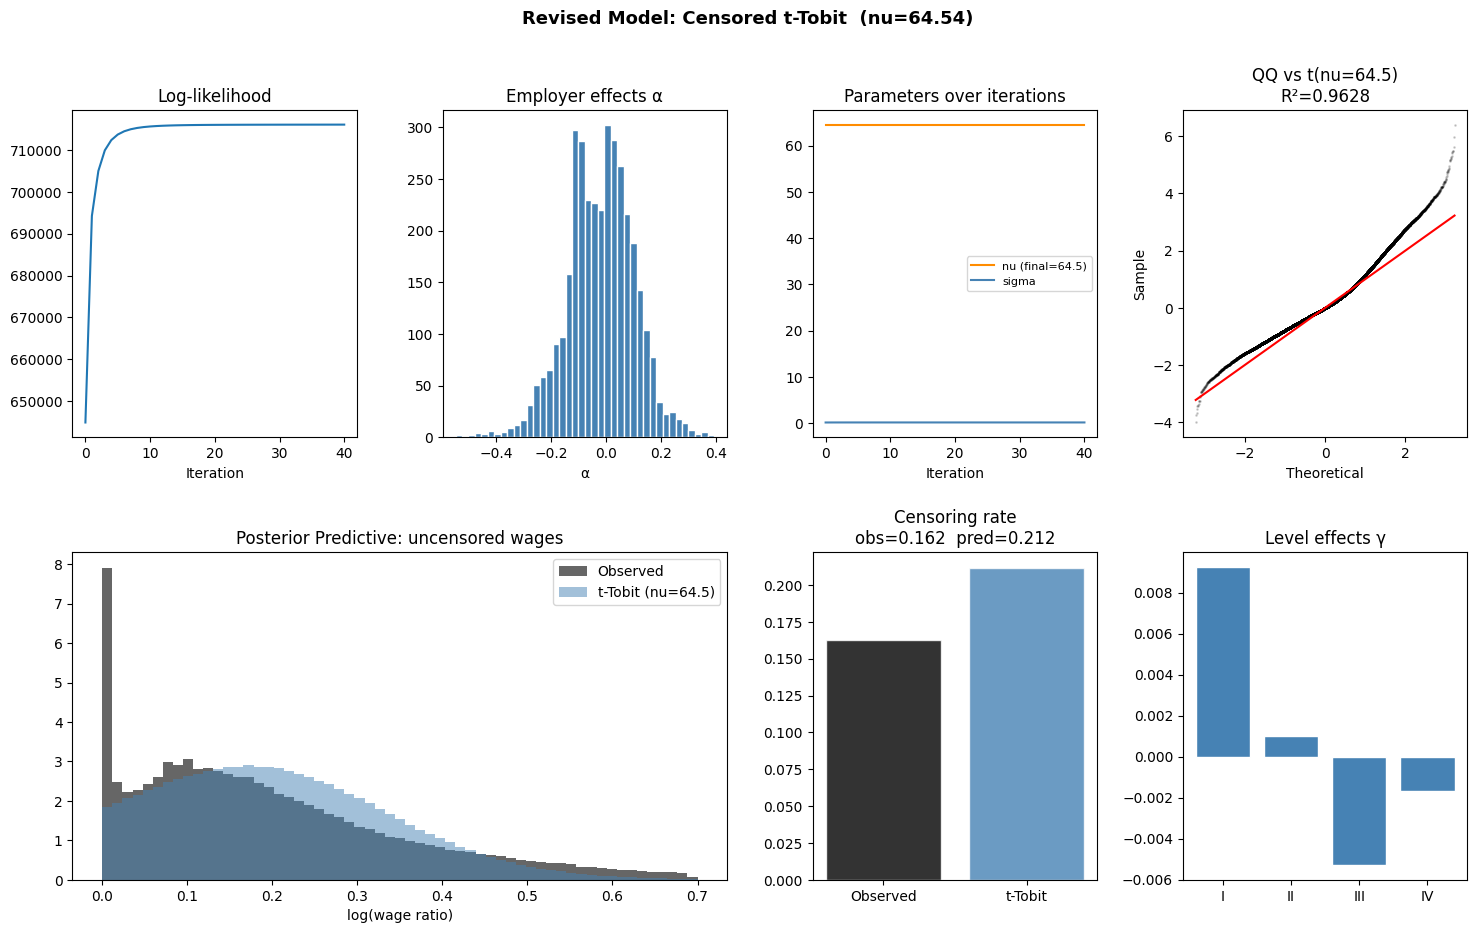

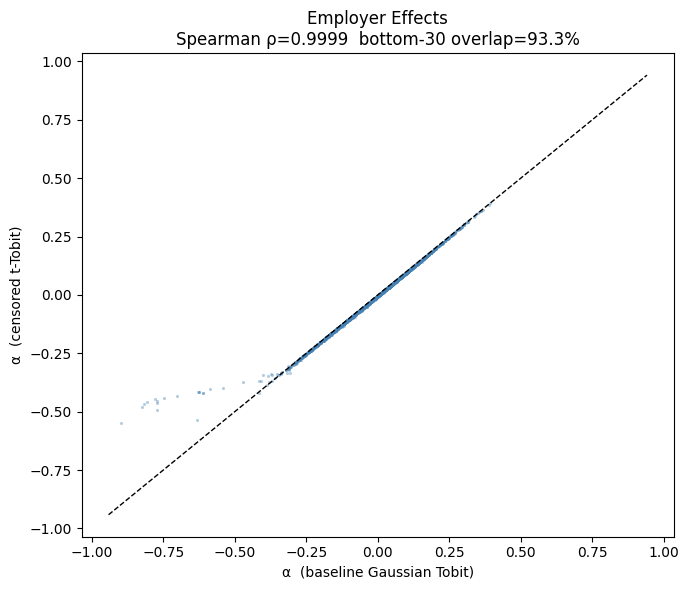

Spearman ρ: 0.9999  |  bottom-30 overlap: 93.3%
CHECK 1: Global distribution ...


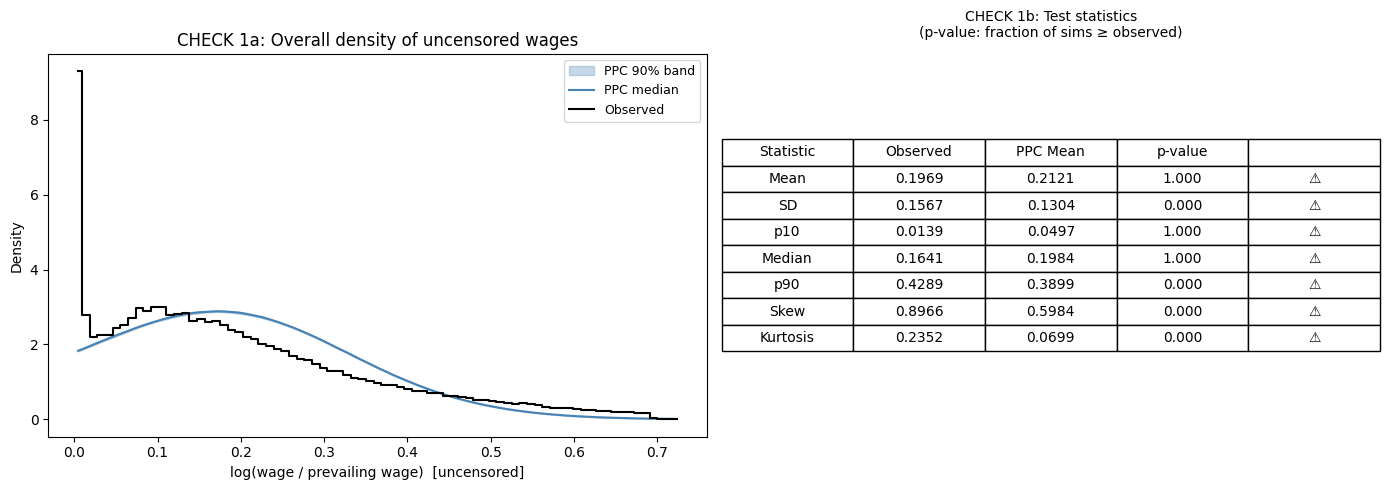

CHECK 2: Censoring rates ...


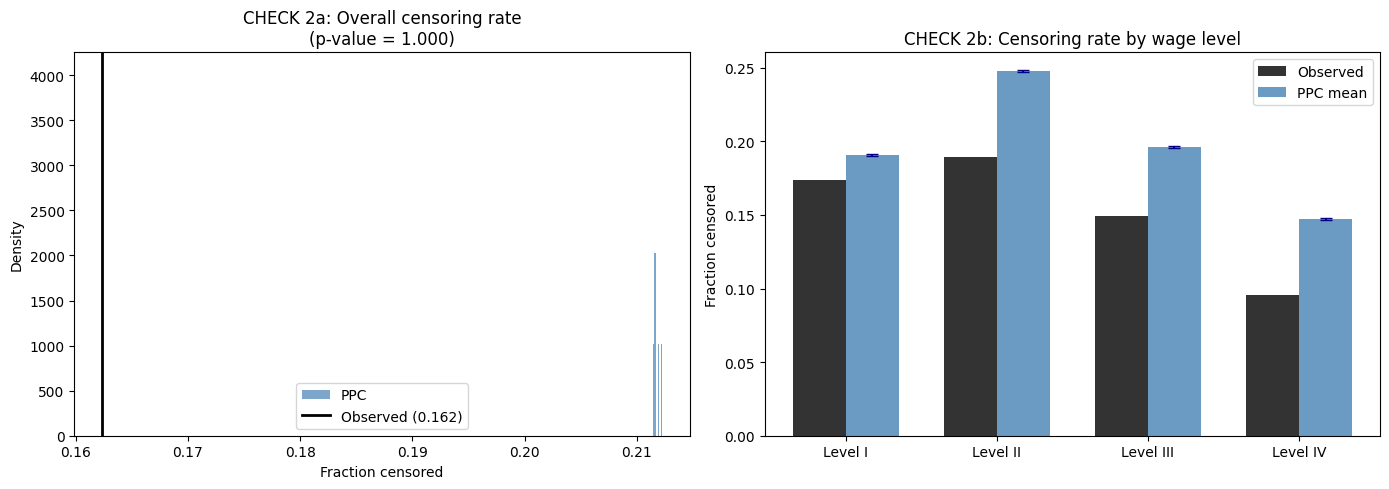

Observed censoring by level: {'I': np.float64(0.174), 'II': np.float64(0.189), 'III': np.float64(0.149), 'IV': np.float64(0.096)}
PPC mean censoring by level: {'I': np.float64(0.191), 'II': np.float64(0.248), 'III': np.float64(0.196), 'IV': np.float64(0.147)}
CHECK 3: Distribution by wage level ...


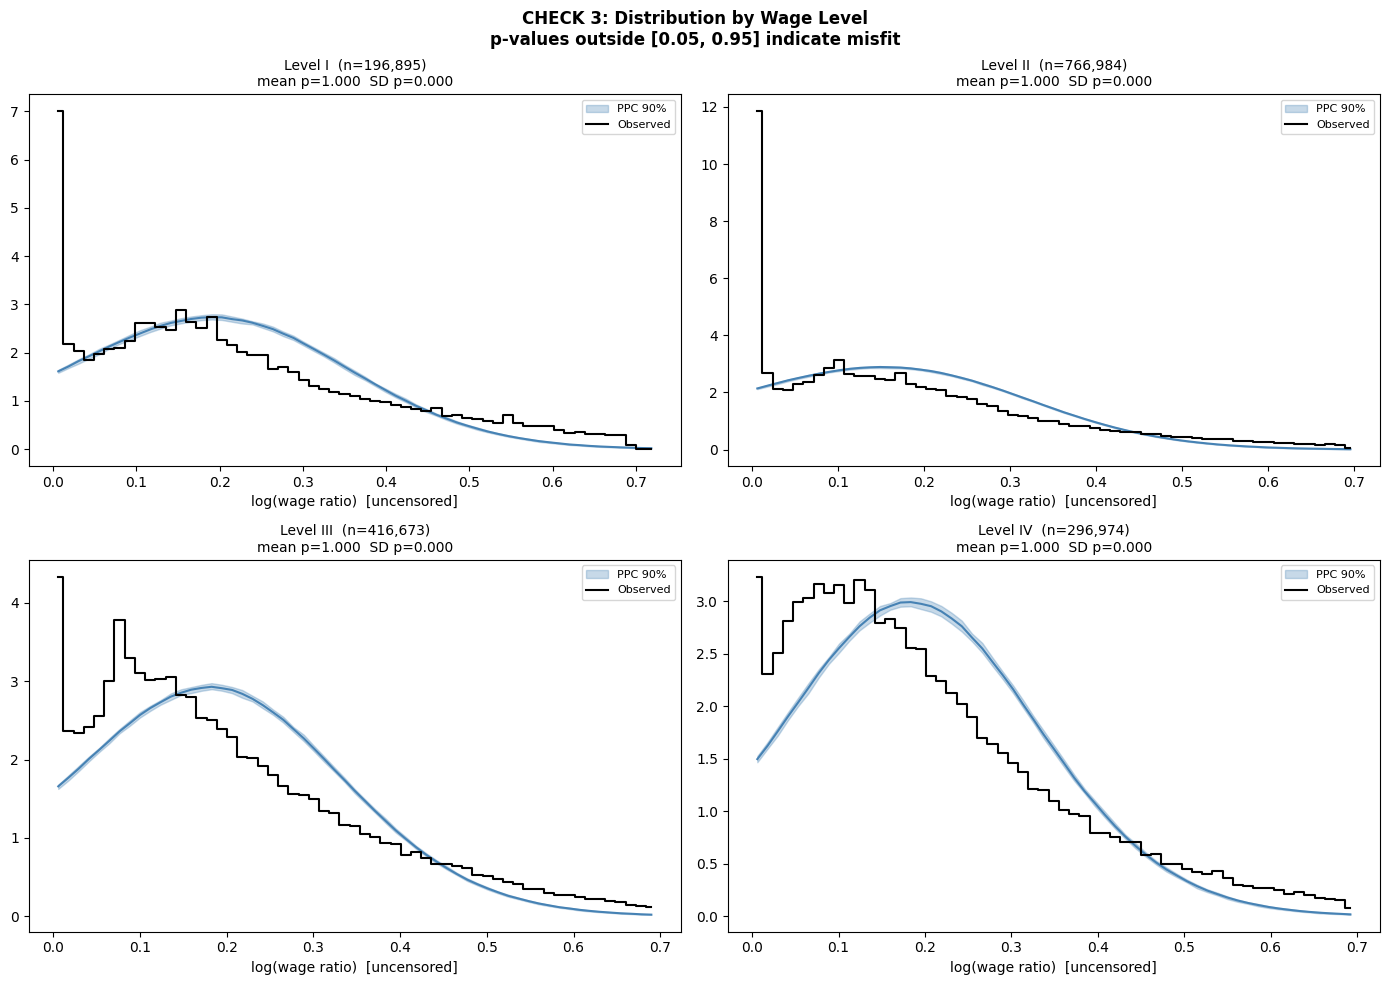

CHECK 4: Employer-level censoring calibration ...


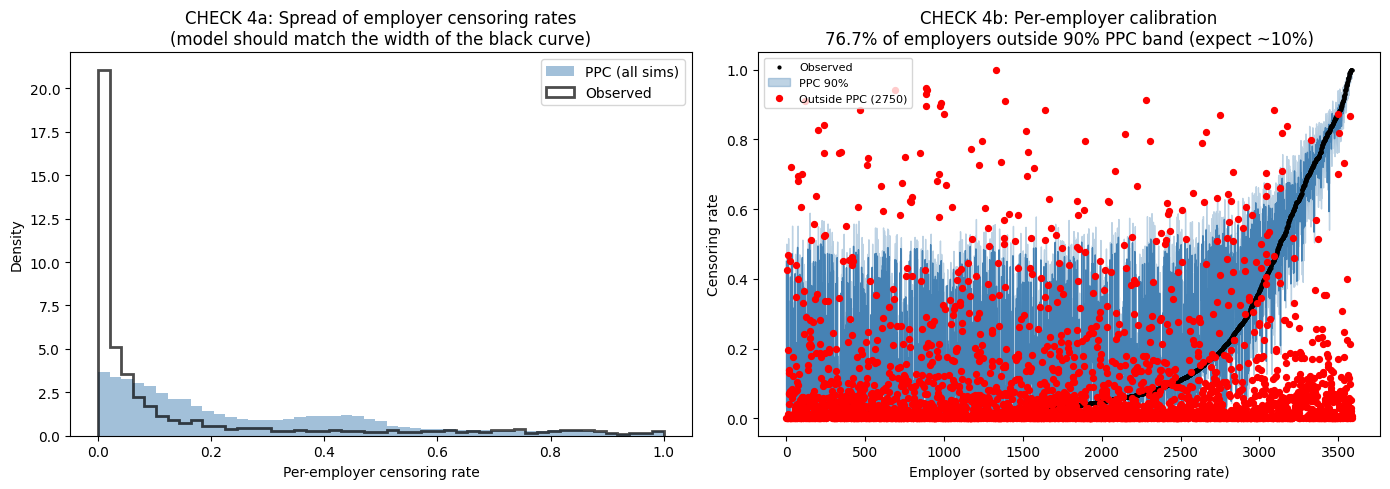

CHECK 5: Residual diagnostics ...


KeyboardInterrupt: 

In [ ]:
"""
Revised Model: Censored t-Distribution Tobit
==============================================
Motivation from PPCs:
  - Check 5a: QQ plot departs from the diagonal in the upper tail,
    indicating heavier-than-Gaussian tails in the residuals.
  - Check 1: predicted p90 and skewness are both too low, consistent
    with the Gaussian underweighting large positive wages.

Fix: replace Normal(mu_i, sigma^2) with a scaled t-distribution:
  y_i* ~ mu_i + sigma * t(nu)

nu (degrees of freedom) is estimated from the data each iteration.
  nu -> inf  recovers the Gaussian Tobit exactly.
  nu = 3-10  gives heavy tails matching the observed upper-tail behavior.

EM via normal-variance-mixture representation:
  y_i* | lambda_i ~ N(mu_i, sigma^2 / lambda_i)
  lambda_i ~ Gamma(nu/2, nu/2)

E-step:
  Uncensored: E[lambda_i | y_i] = (nu+1) / (nu + z_i^2)  [exact, closed form]
              where z_i = (y_i - mu_i) / sigma
  Censored:   use Gaussian truncated normal moments as approximation
              (16% of obs; t vs Gaussian difference is small near the threshold)
              lambda = 1.0 for censored obs (no reweighting)

M-step: weighted penalized LS with lambda_i weights -- identical to
        baseline but with per-observation weights. Extreme uncensored
        wages automatically get small lambda and less influence on mu_i.

nu update: 1D MLE on complete-data lambda weights each iteration.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats, optimize
import warnings
warnings.filterwarnings("ignore")

EPS     = 1e-8
MAX_VAL = 1e6


# =============================================================================
# DATA PREP  (unchanged from model2)
# =============================================================================

def prepare_data(df):
    df = df.copy()
    df["SOC_2DIGIT"] = df["SOC_CODE"].astype(str).str[:2]
    soc_counts = df["SOC_2DIGIT"].value_counts()
    df["SOC_F"] = df["SOC_2DIGIT"].where(
        df["SOC_2DIGIT"].isin(soc_counts[soc_counts >= 100].index), "OTHER")
    state_counts = df["WORKSITE_STATE"].value_counts()
    df["STATE_F"] = df["WORKSITE_STATE"].where(
        df["WORKSITE_STATE"].isin(state_counts[state_counts >= 100].index), "OTHER")
    S  = pd.Categorical(df["SOC_F"]).codes
    ST = pd.Categorical(df["STATE_F"]).codes
    E  = pd.Categorical(df["EMPLOYER_NAME_CLEAN"]).codes
    level_map = {"I":0,"II":1,"III":2,"IV":3}
    L  = df["WAGE_LEVEL_CLEAN"].map(level_map).values
    y  = np.maximum(np.log(df["wage_ratio"].values), 0)
    censored = (y == 0)
    return {
        "y": y, "censored": censored,
        "L": L, "E": E, "S": S, "ST": ST,
        "K": 4,
        "N_E":  len(np.unique(E)),
        "N_S":  len(np.unique(S)),
        "N_ST": len(np.unique(ST)),
    }


# =============================================================================
# GAUSSIAN TRUNCATED MOMENTS  (for censored obs approximation)
# =============================================================================

def truncated_normal_moments(mu, sigma):
    """E[y*|y*<0] and E[(y*)^2|y*<0] under N(mu, sigma^2)."""
    sigma = np.maximum(sigma, EPS)
    a     = np.clip(-mu / sigma, -10, 10)
    phi   = stats.norm.pdf(a)
    Phi   = np.clip(stats.norm.cdf(a), EPS, 1.0)
    ratio = np.clip(phi / Phi, -MAX_VAL, MAX_VAL)
    E1    = mu - sigma * ratio
    E2    = mu**2 + sigma**2 - sigma*(mu + sigma*ratio)*ratio
    return E1, E2


# =============================================================================
# E-STEP
# =============================================================================

def e_step(y, censored, mu, sigma, nu):
    """
    Compute lambda weights and imputed y_star.

    Uncensored (exact):
      lambda_i = (nu+1) / (nu + z_i^2)  where z_i = (y_i-mu_i)/sigma
      This is the posterior mean of lambda_i given y_i under the t-mixture.
      Large |z_i| -> small lambda_i -> outlier is down-weighted in M-step.

    Censored (Gaussian approximation):
      lambda_i = 1.0  (neutral weight)
      y_star_i = E[y*|y*<0] under Gaussian(mu_i, sigma^2)
      This is a good approximation: the t and Gaussian censoring probabilities
      are similar near the threshold (the tail difference is far from 0).
    """
    n      = len(y)
    lam    = np.ones(n)
    y_star  = y.copy()
    y_star2 = y**2

    # Uncensored: exact lambda posterior
    if (~censored).any():
        z2 = np.clip(((y[~censored] - mu[~censored]) / sigma)**2, 0, 1e6)
        lam[~censored] = (nu + 1.0) / (nu + z2)

    # Censored: Gaussian approximation for y_star, lambda=1
    if censored.any():
        E1, E2 = truncated_normal_moments(mu[censored], sigma)
        y_star[censored]  = E1
        y_star2[censored] = E2
        # lam[censored] stays 1.0

    return lam, y_star, y_star2


# =============================================================================
# M-STEP
# =============================================================================

def m_step(y_star, y_star2, lam, L, E, S, ST,
           gamma, alpha, delta, eta,
           sigma2, sigma_E2, sigma_L2, sigma_S2, sigma_ST2):
    """
    Lambda-weighted penalized LS.
    Identical structure to baseline but each obs weighted by lambda_i.
    Large-residual uncensored obs automatically get small lambda -> less pull.
    """
    lam_L  = min(sigma2 / sigma_L2,  MAX_VAL)
    lam_E  = min(sigma2 / sigma_E2,  MAX_VAL)
    lam_S  = min(sigma2 / sigma_S2,  MAX_VAL)
    lam_ST = min(sigma2 / sigma_ST2, MAX_VAL)
    K    = len(gamma);     N_E = len(alpha)
    N_S  = len(delta);     N_ST = len(eta)

    Slw_L  = np.bincount(L,  weights=lam, minlength=K)
    Slw_E  = np.bincount(E,  weights=lam, minlength=N_E)
    Slw_S  = np.bincount(S,  weights=lam, minlength=N_S)
    Slw_ST = np.bincount(ST, weights=lam, minlength=N_ST)
    Sly_L  = np.bincount(L,  weights=lam*y_star, minlength=K)
    Sly_E  = np.bincount(E,  weights=lam*y_star, minlength=N_E)
    Sly_S  = np.bincount(S,  weights=lam*y_star, minlength=N_S)
    Sly_ST = np.bincount(ST, weights=lam*y_star, minlength=N_ST)
    Sly_tot= (lam * y_star).sum()
    Sl_tot = lam.sum()

    for _ in range(30):
        beta0  = (Sly_tot
                  - (lam*(gamma[L]+alpha[E]+delta[S]+eta[ST])).sum()
                  ) / (Sl_tot + EPS)
        gamma  = (Sly_L  - np.bincount(L,  weights=lam*(alpha[E]+delta[S]+eta[ST]), minlength=K)   - Slw_L*beta0) / (Slw_L  + lam_L  + EPS)
        alpha  = (Sly_E  - np.bincount(E,  weights=lam*(gamma[L]+delta[S]+eta[ST]), minlength=N_E) - Slw_E*beta0) / (Slw_E  + lam_E  + EPS)
        delta  = (Sly_S  - np.bincount(S,  weights=lam*(gamma[L]+alpha[E]+eta[ST]), minlength=N_S) - Slw_S*beta0) / (Slw_S  + lam_S  + EPS)
        eta    = (Sly_ST - np.bincount(ST, weights=lam*(gamma[L]+alpha[E]+delta[S]),minlength=N_ST)- Slw_ST*beta0) / (Slw_ST + lam_ST + EPS)

    mu = beta0 + gamma[L] + alpha[E] + delta[S] + eta[ST]

    # sigma^2: lambda-weighted residual variance
    lam_resid2 = lam * np.clip(y_star2 - 2*y_star*mu + mu**2, 0, MAX_VAL)
    sigma2_new = max((lam_resid2.sum() + 0.1) / (Sl_tot + 2), 1e-4)

    return beta0, gamma, alpha, delta, eta, sigma2_new, mu


def update_nu(lam, nu_old):
    """
    Update nu by 1D MLE on complete-data lambda weights.
    Score equation: log(nu/2) - digamma(nu/2) + mean(log(lam) - lam) + 1 = 0
    Solved by brentq; damped toward previous value.
    """
    from scipy.special import digamma
    mean_log_lam = float(np.mean(np.log(np.maximum(lam, EPS))))
    mean_lam     = float(np.mean(lam))

    def score(nu):
        a = nu / 2.0
        return float(np.log(a) - digamma(a) + mean_log_lam - mean_lam + 1)

    try:
        nu_new = optimize.brentq(score, 0.5, 200.0, xtol=0.05, maxiter=50)
        nu_new = 0.7 * nu_old + 0.3 * float(nu_new)
    except Exception:
        nu_new = nu_old

    return float(np.clip(nu_new, 1.5, 200.0))


# =============================================================================
# LOG-LIKELIHOOD
# =============================================================================

def observed_ll(y, censored, mu, sigma, nu):
    sigma = max(sigma, EPS)
    ll    = 0.0
    if (~censored).any():
        ll += stats.t.logpdf(
            y[~censored], df=nu, loc=mu[~censored], scale=sigma).sum()
    if censored.any():
        ll += stats.t.logcdf(
            0.0, df=nu, loc=mu[censored], scale=sigma).sum()
    return ll


# =============================================================================
# FIT MODEL
# =============================================================================

def fit_model(data, max_iter=50, warmup_iters=10, nu_init=10.0):
    y, censored = data['y'], data['censored']
    L, E, S, ST = data['L'], data['E'], data['S'], data['ST']

    gamma  = np.zeros(data['K'])
    alpha  = np.zeros(data['N_E'])
    delta  = np.zeros(data['N_S'])
    eta    = np.zeros(data['N_ST'])
    beta0  = float(np.mean(y[~censored])) if (~censored).any() else 0.2
    sigma2 = float(np.var(y[~censored]))  if (~censored).any() else 0.04
    sigma_E2 = sigma_L2 = sigma_S2 = sigma_ST2 = 0.1
    nu     = float(nu_init)

    def _damp(old, new, w=0.1):
        return (1-w)*old + w*new
    def _update_s(v):
        return max((np.sum(v**2)+0.1)/(len(v)+2), 1e-4)

    lls = []; history = []

    for it in range(max_iter):
        mu = beta0 + gamma[L] + alpha[E] + delta[S] + eta[ST]

        lam, y_star, y_star2 = e_step(y, censored, mu, np.sqrt(sigma2), nu)

        (beta0, gamma, alpha, delta, eta,
         sigma2, mu) = m_step(
            y_star, y_star2, lam, L, E, S, ST,
            gamma, alpha, delta, eta,
            sigma2, sigma_E2, sigma_L2, sigma_S2, sigma_ST2)

        nu = update_nu(lam, nu)

        if it < warmup_iters:
            sigma_E2  = _damp(sigma_E2,  _update_s(alpha))
            sigma_L2  = _damp(sigma_L2,  _update_s(gamma))
            sigma_S2  = _damp(sigma_S2,  _update_s(delta))
            sigma_ST2 = _damp(sigma_ST2, _update_s(eta))

        ll = observed_ll(y, censored, mu, np.sqrt(sigma2), nu)
        lls.append(ll)
        history.append({"sigma": np.sqrt(sigma2), "nu": nu,
                        "sigma_E": np.sqrt(sigma_E2),
                        "lam_mean": float(lam.mean())})

        print(f"iter {it:2d}: ll={ll:,.1f}  sigma={np.sqrt(sigma2):.4f}"
              f"  nu={nu:.2f}  lam_mean={lam.mean():.3f}"
              f"  sigma_E={np.sqrt(sigma_E2):.4f}")

        if it > 3 and abs(lls[-1]-lls[-2]) < 1:
            break

    return {
        "beta0":   beta0, "gamma":   gamma, "alpha":   alpha,
        "delta":   delta, "eta":     eta,
        "sigma":   np.sqrt(sigma2), "nu": nu,
        "sigma_E": np.sqrt(sigma_E2),
        "lls":     lls, "history": history, "data": data,
    }


# =============================================================================
# DIAGNOSTICS
# =============================================================================

def plot_results(result):
    data   = result["data"]
    y      = data["y"]
    sigma  = result["sigma"]
    nu     = result["nu"]
    mu     = (result["beta0"]
              + result["gamma"][data["L"]]
              + result["alpha"][data["E"]]
              + result["delta"][data["S"]]
              + result["eta"][data["ST"]])

    rng = np.random.default_rng(42)
    fig = plt.figure(figsize=(18, 10))
    gs  = gridspec.GridSpec(2, 4, hspace=0.35, wspace=0.3)

    ax = fig.add_subplot(gs[0, 0])
    ax.plot(result["lls"])
    ax.set_title("Log-likelihood"); ax.set_xlabel("Iteration")

    ax = fig.add_subplot(gs[0, 1])
    ax.hist(result["alpha"], bins=40, color="steelblue", edgecolor="white")
    ax.set_title("Employer effects α"); ax.set_xlabel("α")

    ax = fig.add_subplot(gs[0, 2])
    ax.plot([h["nu"]    for h in result["history"]], color="darkorange",
            label=f"nu (final={nu:.1f})")
    ax.plot([h["sigma"] for h in result["history"]], color="steelblue",
            label="sigma")
    ax.set_title("Parameters over iterations")
    ax.legend(fontsize=8); ax.set_xlabel("Iteration")

    # QQ vs t(nu)
    ax = fig.add_subplot(gs[0, 3])
    mask  = y > 0
    resid = (y[mask] - mu[mask]) / sigma
    idx   = rng.choice(len(resid), min(30000, len(resid)), replace=False)
    osm   = np.sort(resid[idx])
    osr   = stats.t(df=nu).ppf(np.linspace(0.001, 0.999, len(osm)))
    ax.scatter(osr, osm, s=1, alpha=0.15, color="black")
    ax.plot([osr.min(), osr.max()], [osr.min(), osr.max()], "r-", lw=1.5)
    r2 = np.corrcoef(osr, osm)[0,1]**2
    ax.set_title(f"QQ vs t(nu={nu:.1f})\nR²={r2:.4f}")
    ax.set_xlabel("Theoretical"); ax.set_ylabel("Sample")

    # Posterior predictive
    ax = fig.add_subplot(gs[1, 0:2])
    y_sim = np.maximum(
        stats.t.rvs(df=nu, loc=mu, scale=sigma, random_state=rng), 0.0)
    bins  = np.linspace(0, 0.7, 60)
    ax.hist(y[y > 0],        bins=bins, density=True, alpha=0.6,
            color="black",     label="Observed")
    ax.hist(y_sim[y_sim > 0],bins=bins, density=True, alpha=0.5,
            color="steelblue", label=f"t-Tobit (nu={nu:.1f})")
    ax.set_title("Posterior Predictive: uncensored wages")
    ax.set_xlabel("log(wage ratio)"); ax.legend()

    ax = fig.add_subplot(gs[1, 2])
    obs_rate  = float(data["censored"].mean())
    pred_rate = float(stats.t.cdf(0, df=nu, loc=mu, scale=sigma).mean())
    ax.bar(["Observed", "t-Tobit"],
           [obs_rate, pred_rate],
           color=["black", "steelblue"], alpha=0.8, edgecolor="white")
    ax.set_title(f"Censoring rate\nobs={obs_rate:.3f}  pred={pred_rate:.3f}")

    ax = fig.add_subplot(gs[1, 3])
    ax.bar(["I","II","III","IV"], result["gamma"],
           color="steelblue", edgecolor="white")
    ax.set_title("Level effects γ")

    plt.suptitle(f"Revised Model: Censored t-Tobit  (nu={nu:.2f})",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("figures/revised_model_diagnostics.png",
                dpi=150, bbox_inches="tight")
    plt.show()


def compare_to_baseline(result_revised, result_baseline, df, top_n=30):
    from scipy import stats as _stats
    alpha_r = result_revised["alpha"]
    alpha_b = result_baseline["alpha"]
    rho     = _stats.spearmanr(alpha_b, alpha_r).statistic
    bot_b   = set(np.argsort(alpha_b)[:top_n])
    bot_r   = set(np.argsort(alpha_r)[:top_n])
    overlap = len(bot_b & bot_r) / top_n

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(alpha_b, alpha_r, s=5, alpha=0.4,
               color="steelblue", linewidths=0)
    lim = max(abs(alpha_b).max(), abs(alpha_r).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=1)
    ax.set_xlabel("α  (baseline Gaussian Tobit)")
    ax.set_ylabel("α  (censored t-Tobit)")
    ax.set_title(f"Employer Effects\nSpearman ρ={rho:.4f}  "
                 f"bottom-{top_n} overlap={overlap:.1%}")
    plt.tight_layout()
    plt.savefig("figures/revised_vs_baseline.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Spearman ρ: {rho:.4f}  |  bottom-{top_n} overlap: {overlap:.1%}")


# =============================================================================
# USAGE
# =============================================================================
#
import os; os.makedirs("figures", exist_ok=True)
data           = prepare_data(df)
result_revised = fit_model(data, nu_init=10.0)
plot_results(result_revised)
compare_to_baseline(result_revised, result, df, top_n=30)

def simulate_yrep(result, n_sim=50, rng=None):
    if rng is None: rng = np.random.default_rng(42)
    data = result["data"]
    mu = (result["beta0"] + result["gamma"][data["L"]]
          + result["alpha"][data["E"]] + result["delta"][data["S"]]
          + result["eta"][data["ST"]])
    y_rep = np.maximum(
        stats.t.rvs(df=result["nu"], loc=mu[None,:], scale=result["sigma"],
                    size=(n_sim, len(mu)), random_state=rng), 0.0)
    return y_rep, mu

run_all_ppc(result_revised, df, n_sim=50)